# Source Code for **Improving TensorSketch Using Complex Random Variables** Experiments

---

## Requirements  

The implementation relies on the following Python toolboxes:

- **NumPy** – numerical linear algebra and FFT operations  
- **SciPy** – sparse matrix handling (when loading datasets)  
- **scikit-learn** – dataset preprocessing (`StandardScaler`, `fetch_openml`)  
- **matplotlib** – visualization of distortion and timing results  
- **urllib** – direct dataset download (UCI datasets)  
- **time** – runtime measurement  

---

## Implementation Overview  

### Our Work  

**Complex-to-Real TensorSketch**  

- Implemented in the `ctr_tensorsketch_features` function in every cell with approach defined in comments. (algorithm proposed in our paper)

These functions implement the proposed improvement to TensorSketch using **Fourth roots-of-unity distributions**. 

The key idea is to

- Replace real-valued sign functions with random function whose values are drawn independently and uniformly from the four fourth roots of unity.    
- Convert complex embeddings to real representations via concatenation of real and imaginary parts (`ctr_stack`).  

This approach aims to:
- Reduce variance of polynomial kernel approximation.
- Improve distortion behavior for high-degree kernels.
- Maintain computational efficiency comparable to classical TensorSketch. 

---

### Baselines for Comparison  

#### 1. Classical Real TensorSketch  

- `real_tensorsketch_features` [1,2]

Implements standard polynomial kernel approximation via:
- CountSketch hashing (`countsketch`)  
- FFT-based convolution  
- Inverse FFT reconstruction  

---

#### 2. Real Johnson–Lindenstrauss (JL) Polynomial Sketches  

- `real_gaussian_features`  [4]
- `real_rademacher_features` [4]

Random projection methods for approximating  
$$
K(x, y) = (x^\top y)^p
$$

---

#### 3. CtR JL Polynomial Sketches

- `ctr_gaussian_features`  [3]
- `ctr_rademacher_features` [3]

Complex-to-Real extensions of JL projections.

---


## Datasets

We use both synthetic and real-world datasets.

### Synthetic Data

For the synthetic experiments, we generate  
$ n = 3000 $ random vectors in $ \mathbb{R}^{d} $ with $ d = 2 $.

- Each coordinate is drawn independently from a standard Gaussian distribution.
- All vectors are ℓ₂-normalized to lie on the unit sphere.
- We consider homogeneous polynomial kernels of degrees:

$$
p \in \{10, 15, 20\}
$$

- The sketch dimension is varied as:

$$
D \in \{100, 300, 500\}
$$

This setting stresses high-degree polynomial behavior in a low-dimensional regime.

---

### Real-World Data

We evaluate all methods on two real-world datasets:

- **MAGIC Gamma Telescope** [6]  
  - $ d = 10 $ real-valued features  
- **COD-RNA** [7]  
  - $ d = 8 $ numerical attributes  

All inputs are treated as real-valued vectors and ℓ₂-normalized prior to sketching.  

For each dataset:

- We subsample up to \( n = 3000 \) points  
  (or use the full dataset if smaller).
- Each configuration (dataset, polynomial degree \( p \), sketch dimension \( D \))  
  is averaged over **20 independent random trials**.

---

## Comparison Metrics

We evaluate sketch quality and efficiency using two metrics.

### 1. KL Divergence

To assess how well a sketch preserves the structure of the degree-\( p \) polynomial kernel matrix, we compute the KL divergence between the exact kernel \( K \) and its sketch-based approximation \( \widehat{K} \).

Since polynomial kernels are nonnegative, we normalize both matrices into discrete distributions:

$$
P_{ij} = \frac{K_{ij}}{\sum_{a,b} K_{ab}},
\qquad
Q_{ij} = \frac{\widehat{K}_{ij}}{\sum_{a,b} \widehat{K}_{ab}}
$$

We report

$$
\mathrm{KL}(K \,\|\, \widehat{K})
=
\sum_{i,j}
P_{ij}
\log\!\left(
\frac{P_{ij}}{Q_{ij} + \varepsilon}
\right)
$$

where $ \varepsilon > 0 $ ensures numerical stability.

Lower KL divergence indicates better preservation of the kernel structure.

---

### 2. Wall-Clock Time

We measure computational efficiency by the wall-clock time required to construct sketch features for a given method and sketch dimension $ D $.

- Timing is measured using `time.perf_counter()`.
- Reported values are averaged over multiple independent trials.
- Only sketch construction time is measured (kernel reconstruction excluded).

Lower runtime indicates better computational efficiency.

---

### Note 

Some additional experiments are conducted in rebuttal period, whose corresponding code are added in **Rebuttal Added** section

---
## References

1. Ninh Pham and Rasmus Pagh. Fast and scalable polynomial kernels via explicit feature maps. In Proceedings of the 19th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD),pages 239–247, New York, NY, 2013. ACM.
2. Ninh Pham and Rasmus Pagh. Tensor sketch: Fast and scalable polynomial kernel approximation, 2025
3. Jonas Wacker, Ruben Ohana, and Maurizio Filippone. Complex-to-real sketches for tensor products with applications to the polynomial kernel. In Proceedings of the 26th International Conference on Artificial Intelligence and Statistics (AISTATS), volume 206, pages 5181–5212, Cambridge, MA, 2023. PMLR. Code: https://github.com/joneswack/dp-rfs
4. Purushottam Kar and Harish Karnick. Random feature maps for dot product kernels. In Proceedings of the Fifteenth International Conference on Artificial Intelligence and Statistics (AISTATS), volume 22, pages 583–591, Cambridge, MA, 2012. JMLR.org
5. Charikar, Moses, Kevin C. Chen, and Martin Farach-Colton. "Finding frequent items in data streams." Theoretical Computer Science 312.1: 3–15 (2004).
6. R. Bock. MAGIC Gamma Telescope. UCI Machine Learning Repository, 2004.
7. Andrew Uzilov, Joshua Keegan, and David Mathews. Detection of non-coding rnas on the basis of predicted secondary structure formation free energy change. BMC bioinformatics, 7:173, 02 2006. 


Loaded 3000 samples, dimension = 10

=== p = 3 ===
Real Gaussian, p=3, D=10, trial=0
Real Gaussian, p=3, D=10, trial=1
Real Gaussian, p=3, D=10, trial=2
Real Gaussian, p=3, D=10, trial=3
Real Gaussian, p=3, D=10, trial=4
Real Gaussian, p=3, D=10, trial=5
Real Gaussian, p=3, D=10, trial=6
Real Gaussian, p=3, D=10, trial=7
Real Gaussian, p=3, D=10, trial=8
Real Gaussian, p=3, D=10, trial=9
Real Gaussian, p=3, D=10, trial=10
Real Gaussian, p=3, D=10, trial=11
Real Gaussian, p=3, D=10, trial=12
Real Gaussian, p=3, D=10, trial=13
Real Gaussian, p=3, D=10, trial=14
Real Gaussian, p=3, D=10, trial=15
Real Gaussian, p=3, D=10, trial=16
Real Gaussian, p=3, D=10, trial=17
Real Gaussian, p=3, D=10, trial=18
Real Gaussian, p=3, D=10, trial=19
Real Gaussian, p=3, D=30, trial=0
Real Gaussian, p=3, D=30, trial=1
Real Gaussian, p=3, D=30, trial=2
Real Gaussian, p=3, D=30, trial=3
Real Gaussian, p=3, D=30, trial=4
Real Gaussian, p=3, D=30, trial=5
Real Gaussian, p=3, D=30, trial=6
Real Gaussian, p=3, D

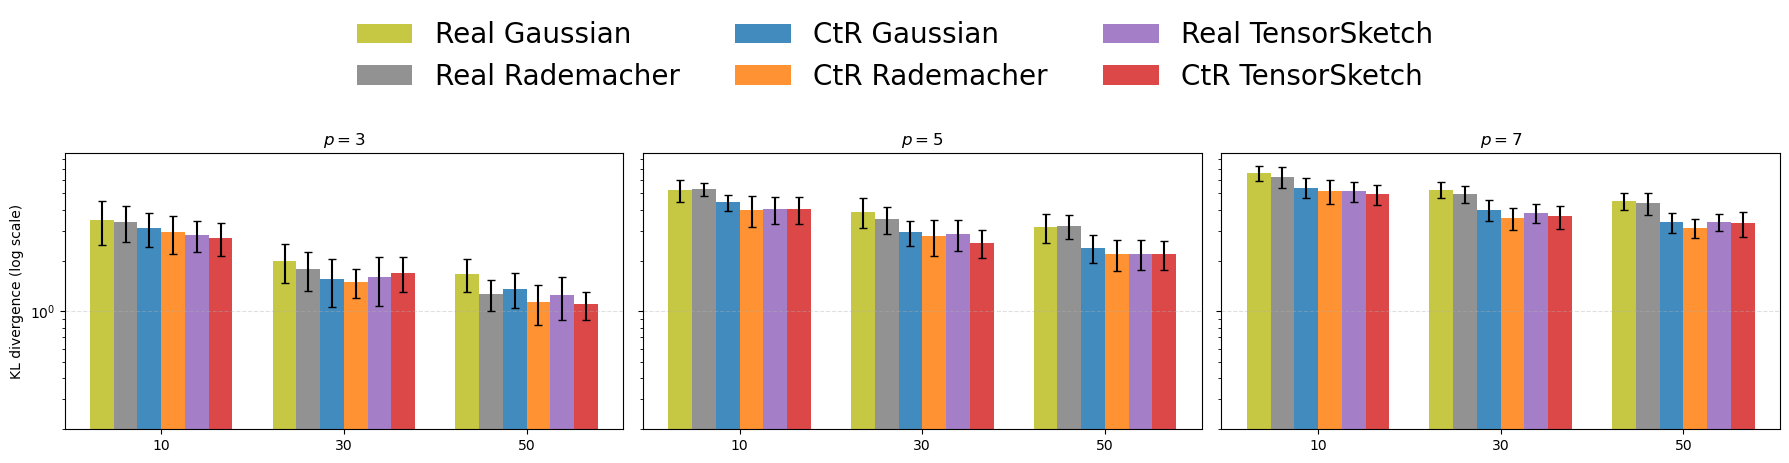

In [5]:
# ============================================================
# Standard library imports
# ============================================================

import random                  # Python RNG (used for roots of unity)
import math                    # Basic mathematical functions
import cmath                   # Complex number support (for CtR features)
import numpy as np             # Numerical linear algebra
import matplotlib.pyplot as plt  # Plotting utilities
import urllib.request          # Dataset download from URL
from sklearn.preprocessing import StandardScaler  # Feature standardization

# ============================================================
# Global configuration
# ============================================================

# Fix random seeds for reproducibility of all experiments.
# This ensures identical results across runs.
random.seed(0)
np.random.seed(0)

# Number of samples used from the dataset
n = 3000

# Degrees of polynomial kernel to evaluate
p_list = [3, 5, 7]

# Number of independent trials per configuration
# Used to compute mean and standard deviation of KL divergence
trials = 20


# ============================================================
# Utility functions
# ============================================================

def l2_normalize(x):
    """
    ℓ2-normalizes a vector.
    Ensures all input vectors lie on the unit sphere.

    This is important because polynomial kernel magnitude
    depends on vector norms.
    """
    norm = np.linalg.norm(x)
    return x if norm == 0 else x / norm


def roots_of_unity():
    """
    Returns a random 4th root of unity:
    {1, i, -1, -i}

    Used in complex Rademacher projections
    for CtR (Complex-to-Real) sketches.
    """
    return cmath.exp(1j * math.pi / 2 * random.randint(0, 3))


def ctr_stack(Zc):
    """
    Converts complex feature matrix into real-valued representation
    by concatenating real and imaginary parts.

    If Zc ∈ ℂ^{n×Dc},
    output is in ℝ^{n×(2Dc)}.

    This ensures compatibility with real kernel computation.
    """
    return np.concatenate([Zc.real, Zc.imag], axis=1)


# ============================================================
# MAGIC Dataset Loading
# ============================================================

print("Downloading MAGIC dataset...")

# UCI MAGIC Gamma Telescope dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data"

# Download and parse lines
lines = urllib.request.urlopen(url).read().decode().strip().split("\n")

X_list = []

# Extract first n samples and first 10 real-valued features
for line in lines[:n]:
    feats = list(map(float, line.split(",")[:10]))
    X_list.append(feats)

# Convert to NumPy array
X = np.array(X_list, dtype=float)

# Standardize features (zero mean, unit variance)
X = StandardScaler().fit_transform(X)

# ℓ2-normalize each sample
X = np.array([l2_normalize(x) for x in X])

# Extract final dimensions
n, d = X.shape
print(f"Loaded {n} samples, dimension = {d}")

# Embedding dimensions tested
D_vals = [d, 3*d, 5*d]

# Ensure D is even (required for CtR which splits into complex halves)
D_vals = [D if D % 2 == 0 else D+1 for D in D_vals]


# ============================================================
# Exact Polynomial Kernel
# ============================================================

def exact_kernel_matrix(X, p):
    """
    Computes exact degree-p homogeneous polynomial kernel:

        K(x, y) = (xᵀ y)^p

    Returns full n×n Gram matrix.
    """
    return (X @ X.T) ** p


# ============================================================
# KL Divergence
# ============================================================

def kl_divergence(Kh, K, eps=1e-12):
    """
    Computes KL divergence between normalized Gram matrices.

    Both matrices are interpreted as discrete distributions
    after normalization by total mass.

    This measures global structural distortion of the kernel.
    """

    # Ensure non-negativity (numerical safety)
    K = np.maximum(K, 0)
    Kh = np.maximum(Kh, 0)

    # Normalize into probability distributions
    P = K / (K.sum() + eps)
    Q = Kh / (Kh.sum() + eps)

    return np.sum(P * np.log((P + eps) / (Q + eps)))


# ============================================================
# Real JL Sketches (Unoptimized, explicit loops)
# ============================================================

def real_gaussian_features(X, D, p):
    """
    Real Gaussian JL sketch for degree-p polynomial kernel.

    For each degree:
        Draw W ~ N(0,1)
        Multiply projections elementwise

    Final scaling: 1/sqrt(D)
    """
    n, d = X.shape
    Z = np.ones((n, D))

    for _ in range(p):
        W = np.random.randn(D, d)
        Z *= np.array([[sum(W[j, k] * x[k] for k in range(d))
                        for j in range(D)] for x in X])

    return Z / math.sqrt(D)


def real_rademacher_features(X, D, p):
    """
    Same as Gaussian but using ±1 Rademacher variables.
    """
    n, d = X.shape
    Z = np.ones((n, D))

    for _ in range(p):
        W = np.random.choice([-1.0, 1.0], size=(D, d))
        Z *= np.array([[sum(W[j, k] * x[k] for k in range(d))
                        for j in range(D)] for x in X])

    return Z / math.sqrt(D)


# ============================================================
# Complex-to-Real JL Sketches
# ============================================================

def ctr_gaussian_features(X, D, p):
    """
    CtR Gaussian JL sketch.

    Uses D/2 complex features.
    Final scaling: sqrt(2/D)
    """
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        W = np.random.randn(Dc, d) + 1j*np.random.randn(Dc, d)
        Zc *= np.array([[sum(W[j, k] * x[k] for k in range(d))
                         for j in range(Dc)] for x in X])

    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


def ctr_rademacher_features(X, D, p):
    """
    CtR Rademacher sketch using random roots of unity.
    """
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        W = np.array([[roots_of_unity() for _ in range(d)]
                      for _ in range(Dc)], dtype=complex)

        Zc *= np.array([[sum(W[j, k] * x[k] for k in range(d))
                         for j in range(Dc)] for x in X])

    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


# ============================================================
# CountSketch primitive
# ============================================================

def countsketch(x, h, s, D):
    """
    Applies CountSketch transform to vector x.

    h : hash indices
    s : random signs (or roots of unity)
    D : output dimension
    """
    z = [0] * D
    for i in range(len(x)):
        z[h[i]] += s[i] * x[i]
    return z


# ============================================================
# TensorSketch
# ============================================================

def real_tensorsketch_features(X, D, p):
    """
    Real TensorSketch implementation.

    Uses FFT to approximate polynomial kernel
    via CountSketch convolution.
    """
    n, d = X.shape
    Z_fft = np.ones((n, D), dtype=complex)

    for _ in range(p):
        h = np.random.randint(0, D, size=d)
        s = np.random.choice([-1, 1], size=d)

        Z = np.zeros((n, D))
        for i in range(n):
            Z[i] = countsketch(X[i], h, s, D)

        Z_fft *= np.fft.fft(Z, axis=1)

    return np.fft.ifft(Z_fft, axis=1).real / math.sqrt(D)


def ctr_tensorsketch_features(X, D, p):
    """
    CtR TensorSketch variant.

    Uses complex CountSketch with roots of unity.
    """
    Dc = D // 2
    n, d = X.shape
    Z_fft = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        h = np.random.randint(0, Dc, size=d)
        s = [roots_of_unity() for _ in range(d)]

        Z = np.zeros((n, Dc), dtype=complex)
        for i in range(n):
            Z[i] = countsketch(X[i], h, s, Dc)

        Z_fft *= np.fft.fft(Z, axis=1)

    Zc = np.fft.ifft(Z_fft, axis=1)
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


# ============================================================
# Kernel from features
# ============================================================

def kernel_from_features(Z):
    """
    Computes approximate kernel matrix from feature map:

        K_hat = Z Zᵀ
    """
    return Z @ Z.T


# ============================================================
# Methods evaluated
# ============================================================

methods = [
    ("Real Gaussian", real_gaussian_features),
    ("Real Rademacher", real_rademacher_features),
    ("CtR Gaussian", ctr_gaussian_features),
    ("CtR Rademacher", ctr_rademacher_features),
    ("Real TensorSketch", real_tensorsketch_features),
    ("CtR TensorSketch", ctr_tensorsketch_features),
]


# ============================================================
# Main experiment loop
# ============================================================

results_mean = {p: {} for p in p_list}
results_std  = {p: {} for p in p_list}

for p in p_list:
    print(f"\n=== p = {p} ===")

    # Compute exact kernel once per degree
    K_true = exact_kernel_matrix(X, p)

    for name, fn in methods:
        means, stds = [], []

        for D in D_vals:
            errs = []

            for t in range(trials):
                print(f"{name}, p={p}, D={D}, trial={t}")

                # Compute feature map
                Z = fn(X, D, p)

                # Compute approximate kernel
                K_hat = kernel_from_features(Z)

                # Compute distortion metric
                errs.append(kl_divergence(K_hat, K_true))

            means.append(np.mean(errs))
            stds.append(np.std(errs, ddof=1))

        results_mean[p][name] = means
        results_std[p][name]  = stds


# ============================================================
# Plotting
# ============================================================

COLOR_MAP = {
    "Real Gaussian": "#bcbd22",
    "Real Rademacher": "#7f7f7f",
    "CtR Gaussian": "#1f77b4",
    "CtR Rademacher": "#ff7f0e",
    "Real TensorSketch": "#9467bd",
    "CtR TensorSketch": "#d62728",
}

bar_width = 0.13
xpos = np.arange(len(D_vals))

fig, axes = plt.subplots(1, len(p_list), figsize=(18,4), sharey=True)

for ax, p in zip(axes, p_list):
    for i, (name, _) in enumerate(methods):
        ax.bar(xpos + i*bar_width,
               results_mean[p][name],
               bar_width,
               yerr=results_std[p][name],
               capsize=3,
               color=COLOR_MAP[name],
               alpha=0.85,
               label=name)

    ax.set_title(f"$p={p}$")
    ax.set_xticks(xpos + bar_width*(len(methods)-1)/2)
    ax.set_xticklabels(D_vals)
    ax.set_yscale("log")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

axes[0].set_ylabel("KL divergence (log scale)")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="upper center",
           bbox_to_anchor=(0.5, 1.18),
           ncol=3,
           frameon=False,
           fontsize=20)

plt.tight_layout(rect=[0,0,1,0.88])
plt.savefig("KL_Divergence_magic_p_CtR_unoptimizedJL.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

Loaded 3000 samples, d = 10

=== Timing p=3 ===
  p=3, D=10, method=Real Gaussian, trial=0
  p=3, D=10, method=Real Gaussian, trial=10
  p=3, D=10, method=Real Gaussian, trial=20
  p=3, D=10, method=Real Gaussian, trial=30
  p=3, D=10, method=Real Gaussian, trial=40
  p=3, D=10, method=Real Rademacher, trial=0
  p=3, D=10, method=Real Rademacher, trial=10
  p=3, D=10, method=Real Rademacher, trial=20
  p=3, D=10, method=Real Rademacher, trial=30
  p=3, D=10, method=Real Rademacher, trial=40
  p=3, D=10, method=CtR Gaussian, trial=0
  p=3, D=10, method=CtR Gaussian, trial=10
  p=3, D=10, method=CtR Gaussian, trial=20
  p=3, D=10, method=CtR Gaussian, trial=30
  p=3, D=10, method=CtR Gaussian, trial=40
  p=3, D=10, method=CtR Rademacher, trial=0
  p=3, D=10, method=CtR Rademacher, trial=10
  p=3, D=10, method=CtR Rademacher, trial=20
  p=3, D=10, method=CtR Rademacher, trial=30
  p=3, D=10, method=CtR Rademacher, trial=40
  p=3, D=10, method=Real TensorSketch, trial=0
  p=3, D=10, method

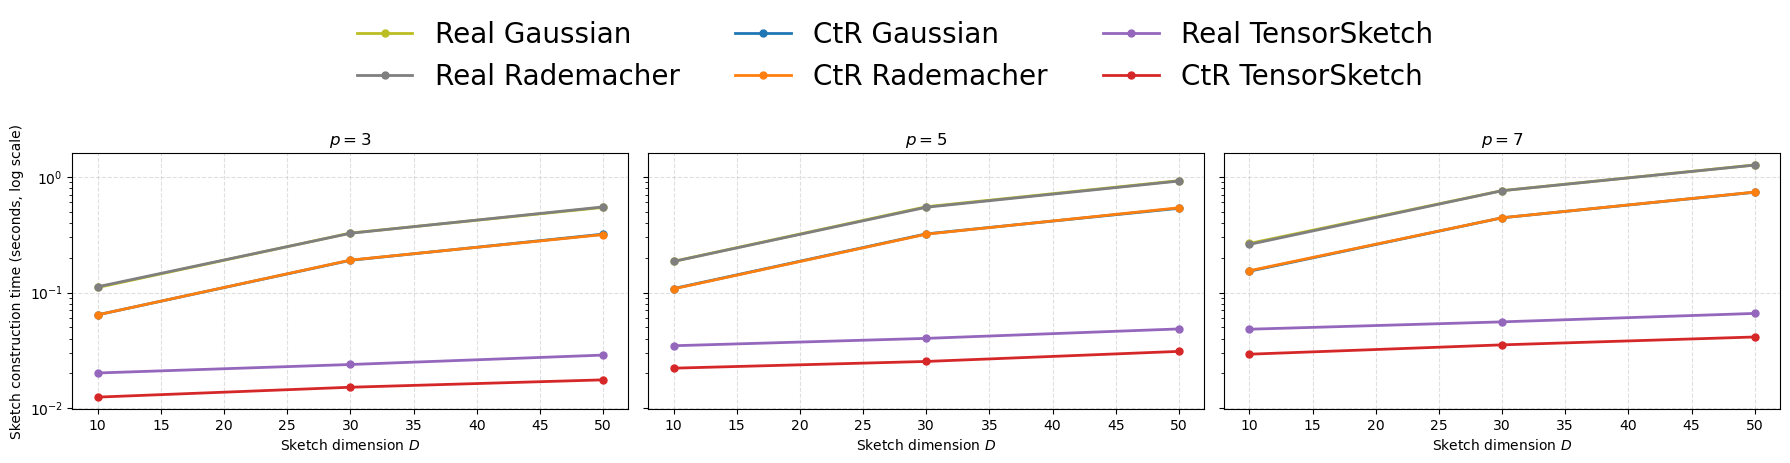

In [4]:
# ============================================================
# Standard library imports
# ============================================================

import random                      # Python random number generator
import math                        # Mathematical constants and functions
import cmath                       # Complex number utilities
import numpy as np                 # Numerical linear algebra library
import matplotlib.pyplot as plt    # Plotting library
import urllib.request              # Used to download dataset from URL
import time                        # High-precision timing measurements
from sklearn.preprocessing import StandardScaler  # Feature standardization


# ============================================================
# Global configuration
# ============================================================

# Fix all random seeds to ensure full reproducibility.
# This guarantees identical sketches across runs.
random.seed(0)
np.random.seed(0)

# Number of samples extracted from dataset
n = 3000

# Degrees of homogeneous polynomial kernel evaluated
p_list = [3, 5, 7]

# Number of independent repetitions per configuration
# Used to compute mean sketch construction time
trials = 50


# ============================================================
# Utility functions
# ============================================================

def l2_normalize(x):
    """
    ℓ2-normalizes a vector.

    Ensures all input vectors lie on the unit sphere.
    This is important because polynomial kernel magnitude
    depends on input norms.
    """
    nrm = np.linalg.norm(x)
    return x if nrm == 0 else x / nrm


def roots_of_unity():
    """
    Returns a random 4th root of unity:
        {1, i, -1, -i}

    Used in complex Rademacher projections
    for CtR (Complex-to-Real) feature maps.
    """
    return cmath.exp(1j * math.pi / 2 * random.randint(0, 3))


def ctr_stack(Zc):
    """
    Converts complex feature matrix Zc ∈ ℂ^{n×Dc}
    into real-valued matrix ∈ ℝ^{n×(2Dc)}
    by concatenating real and imaginary parts.

    Required to interface with real-valued downstream operations.
    """
    return np.concatenate([Zc.real, Zc.imag], axis=1)


# ============================================================
# MAGIC Dataset Loading and Preprocessing
# ============================================================

print("Downloading MAGIC dataset...")

# UCI MAGIC Gamma Telescope dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data"

# Download and split into rows
lines = urllib.request.urlopen(url).read().decode().strip().split("\n")

X_list = []

# Extract first n samples and first 10 numerical features
for line in lines[:n]:
    feats = list(map(float, line.split(",")[:10]))
    X_list.append(feats)

# Convert to NumPy array
X = np.array(X_list, dtype=float)

# Standardize each feature to zero mean, unit variance
X = StandardScaler().fit_transform(X)

# ℓ2-normalize each sample
X = np.array([l2_normalize(x) for x in X])

# Extract final dimensions
n, d = X.shape
print(f"Loaded {n} samples, d = {d}")

# Sketch dimensions tested
D_vals = [d, 3*d, 5*d]

# Ensure even dimensionality (CtR requires D divisible by 2)
D_vals = [D if D % 2 == 0 else D+1 for D in D_vals]


# ============================================================
# Real JL Sketches (Unoptimized loop-based implementation)
# ============================================================

def real_gaussian_features(X, D, p):
    """
    Real Gaussian JL feature map for degree-p polynomial kernel.

    For each of p repetitions:
        - Draw Gaussian projection matrix W ~ N(0,1)
        - Multiply projections elementwise

    Final normalization: 1/sqrt(D)

    Computational complexity per call:
        O(p * n * D * d)
    """
    n, d = X.shape
    Z = np.ones((n, D))

    for _ in range(p):
        W = np.random.randn(D, d)
        Z *= np.array([[sum(W[j, k] * x[k] for k in range(d))
                        for j in range(D)] for x in X])

    return Z / math.sqrt(D)


def real_rademacher_features(X, D, p):
    """
    Same as real Gaussian sketch, but with Rademacher (±1) entries.

    Maintains identical computational complexity.
    """
    n, d = X.shape
    Z = np.ones((n, D))

    for _ in range(p):
        W = np.random.choice([-1.0, 1.0], size=(D, d))
        Z *= np.array([[sum(W[j, k] * x[k] for k in range(d))
                        for j in range(D)] for x in X])

    return Z / math.sqrt(D)


# ============================================================
# Complex-to-Real JL Sketches (Unoptimized)
# ============================================================

def ctr_gaussian_features(X, D, p):
    """
    CtR Gaussian sketch.

    Uses D/2 complex projections and rescales by sqrt(2/D)
    to preserve unbiasedness when converted to real features.

    Computational complexity:
        O(p * n * (D/2) * d)
    """
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        W = np.random.randn(Dc, d) + 1j*np.random.randn(Dc, d)
        Zc *= np.array([[sum(W[j, k] * x[k] for k in range(d))
                         for j in range(Dc)] for x in X])

    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


def ctr_rademacher_features(X, D, p):
    """
    CtR Rademacher sketch using random roots of unity.
    """
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        W = np.array([[roots_of_unity() for _ in range(d)]
                      for _ in range(Dc)], dtype=complex)

        Zc *= np.array([[sum(W[j, k] * x[k] for k in range(d))
                         for j in range(Dc)] for x in X])

    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


# ============================================================
# TensorSketch Implementation
# ============================================================

def countsketch(x, h, s, D):
    """
    Applies CountSketch transform to vector x.

    h : hash indices
    s : random signs or roots of unity
    D : output dimension
    """
    z = [0] * D
    for i in range(len(x)):
        z[h[i]] += s[i] * x[i]
    return z


def real_tensorsketch_features(X, D, p):
    """
    Real TensorSketch via FFT-based convolution.

    Complexity:
        O(p * (nD + D log D))
    """
    n, d = X.shape
    Z_fft = np.ones((n, D), dtype=complex)

    for _ in range(p):
        h = np.random.randint(0, D, size=d)
        s = np.random.choice([-1, 1], size=d)

        Z = np.zeros((n, D))
        for i in range(n):
            Z[i] = countsketch(X[i], h, s, D)

        Z_fft *= np.fft.fft(Z, axis=1)

    return np.fft.ifft(Z_fft, axis=1).real / math.sqrt(D)


def ctr_tensorsketch_features(X, D, p):
    """
    CtR TensorSketch variant.
    """
    Dc = D // 2
    n, d = X.shape
    Z_fft = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        h = np.random.randint(0, Dc, size=d)
        s = [roots_of_unity() for _ in range(d)]

        Z = np.zeros((n, Dc), dtype=complex)
        for i in range(n):
            Z[i] = countsketch(X[i], h, s, Dc)

        Z_fft *= np.fft.fft(Z, axis=1)

    Zc = np.fft.ifft(Z_fft, axis=1)
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


# ============================================================
# Timing Experiment
# ============================================================

# List of evaluated sketch methods
methods = [
    ("Real Gaussian", real_gaussian_features),
    ("Real Rademacher", real_rademacher_features),
    ("CtR Gaussian", ctr_gaussian_features),
    ("CtR Rademacher", ctr_rademacher_features),
    ("Real TensorSketch", real_tensorsketch_features),
    ("CtR TensorSketch", ctr_tensorsketch_features),
]

# Dictionary to store mean sketch construction times
times = {p: {name: [] for name, _ in methods} for p in p_list}

for p in p_list:
    print(f"\n=== Timing p={p} ===")

    for D in D_vals:
        for name, fn in methods:
            tvals = []

            for t in range(trials):

                if t % 10 == 0:
                    print(f"  p={p}, D={D}, method={name}, trial={t}")

                # Measure sketch construction time only
                start = time.perf_counter()
                _ = fn(X, D, p)
                tvals.append(time.perf_counter() - start)

            # Store mean time across trials
            times[p][name].append(np.mean(tvals))


# ============================================================
# Plotting timing results
# ============================================================

COLOR_MAP = {
    "Real Gaussian": "#bcbd22",
    "Real Rademacher": "#7f7f7f",
    "CtR Gaussian": "#1f77b4",
    "CtR Rademacher": "#ff7f0e",
    "Real TensorSketch": "#9467bd",
    "CtR TensorSketch": "#d62728",
}

fig, axes = plt.subplots(1, len(p_list), figsize=(18,4), sharey=True)

for ax, p in zip(axes, p_list):

    for name in times[p]:
        ax.plot(D_vals,
                times[p][name],
                marker="o",
                linewidth=2,
                markersize=5,
                color=COLOR_MAP[name],
                label=name)

    ax.set_title(f"$p={p}$")
    ax.set_xlabel("Sketch dimension $D$")
    ax.set_yscale("log")
    ax.grid(True, linestyle="--", alpha=0.4)

axes[0].set_ylabel("Sketch construction time (seconds, log scale)")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="upper center",
           bbox_to_anchor=(0.5, 1.18),
           ncol=3,
           frameon=False,
           fontsize=20)

plt.tight_layout(rect=[0,0,1,0.88])
plt.savefig("time_magic_sketches_CtR_unoptimized.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

Detected dimension d=8
Loaded 3000 samples

=== p = 3 ===
Real Gaussian, p=3, D=8, trial=0
Real Gaussian, p=3, D=8, trial=1
Real Gaussian, p=3, D=8, trial=2
Real Gaussian, p=3, D=8, trial=3
Real Gaussian, p=3, D=8, trial=4
Real Gaussian, p=3, D=8, trial=5
Real Gaussian, p=3, D=8, trial=6
Real Gaussian, p=3, D=8, trial=7
Real Gaussian, p=3, D=8, trial=8
Real Gaussian, p=3, D=8, trial=9
Real Gaussian, p=3, D=8, trial=10
Real Gaussian, p=3, D=8, trial=11
Real Gaussian, p=3, D=8, trial=12
Real Gaussian, p=3, D=8, trial=13
Real Gaussian, p=3, D=8, trial=14
Real Gaussian, p=3, D=8, trial=15
Real Gaussian, p=3, D=8, trial=16
Real Gaussian, p=3, D=8, trial=17
Real Gaussian, p=3, D=8, trial=18
Real Gaussian, p=3, D=8, trial=19
Real Gaussian, p=3, D=24, trial=0
Real Gaussian, p=3, D=24, trial=1
Real Gaussian, p=3, D=24, trial=2
Real Gaussian, p=3, D=24, trial=3
Real Gaussian, p=3, D=24, trial=4
Real Gaussian, p=3, D=24, trial=5
Real Gaussian, p=3, D=24, trial=6
Real Gaussian, p=3, D=24, trial=7


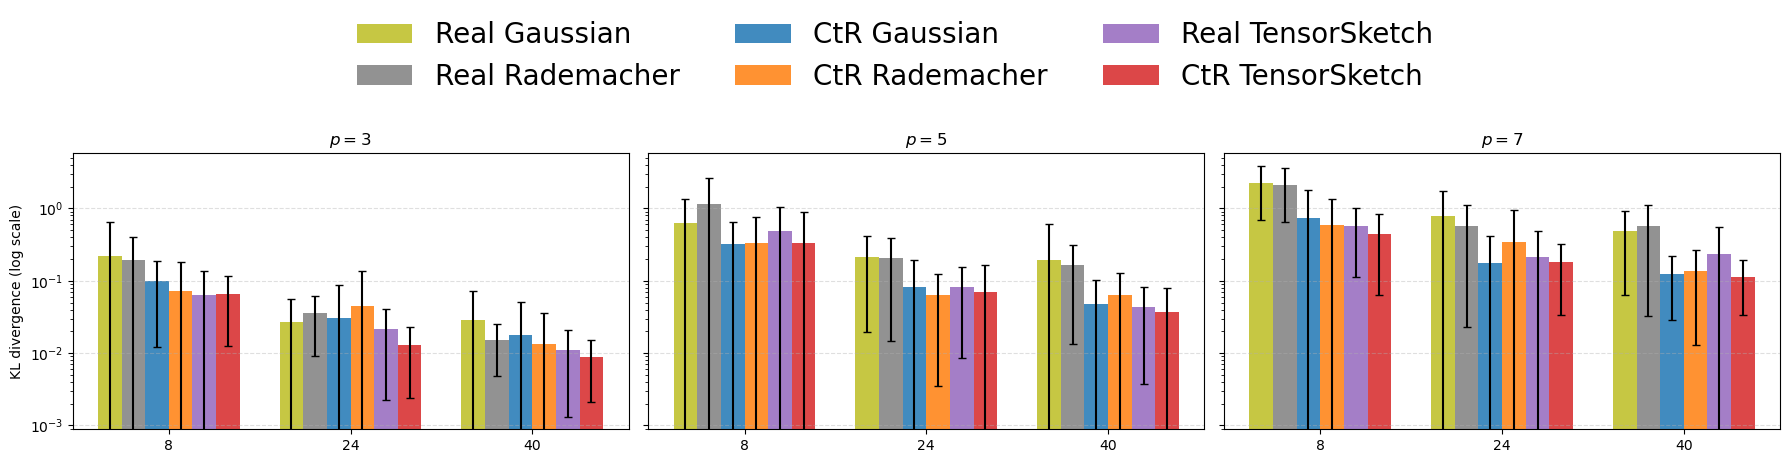

In [6]:
# ============================================================
# Standard library imports
# ============================================================

import random                      # Python random number generator
import math                        # Mathematical functions
import cmath                       # Complex number support
import numpy as np                 # Numerical linear algebra
import matplotlib.pyplot as plt    # Plotting utilities
import time                        # Timing (not used in this script but retained for completeness)
import scipy.sparse                # Sparse matrix detection
from sklearn.datasets import fetch_openml  # Dataset loader from OpenML


# ============================================================
# Global configuration
# ============================================================

# Fix all random seeds for reproducibility.
# Ensures identical sketch realizations across runs.
random.seed(0)
np.random.seed(0)

# Number of samples used from dataset
n = 3000

# Polynomial kernel degrees evaluated
p_list = [3, 5, 7]

# Number of independent trials per configuration
# Used to compute mean and standard deviation of KL divergence
trials = 20


# ============================================================
# Utility functions
# ============================================================

def l2_normalize(x):
    """
    ℓ2-normalizes input vector.

    Ensures all samples lie on the unit sphere.
    This removes scaling effects from the polynomial kernel.
    """
    x = np.asarray(x, dtype=float)
    nrm = np.linalg.norm(x)
    return x if nrm == 0 else x / nrm


def roots_of_unity():
    """
    Returns a uniformly random 4th root of unity:
        {1, i, -1, -i}

    Used for complex Rademacher projections
    in CtR sketches.
    """
    return cmath.exp(1j * math.pi / 2 * random.randint(0, 3))


def ctr_stack(Zc):
    """
    Converts complex feature matrix Zc ∈ ℂ^{n×Dc}
    into real-valued matrix ∈ ℝ^{n×(2Dc)}
    by concatenating real and imaginary parts.

    Required for real-valued kernel reconstruction.
    """
    return np.concatenate([Zc.real, Zc.imag], axis=1)


# ============================================================
# Load COD-RNA dataset (OpenML ID: 351)
# ============================================================

print("Downloading and reading cod-rna dataset...")

# Fetch dataset from OpenML repository
dataset = fetch_openml(data_id=351, as_frame=False)

# Handle possible sparse representation
if scipy.sparse.issparse(dataset.data):
    X_raw = dataset.data.toarray()
else:
    X_raw = dataset.data

# Extract original feature dimension
d = X_raw.shape[1]
print(f"Detected dimension d={d}")

# ℓ2-normalize first n samples
X = np.array([l2_normalize(X_raw[i])
              for i in range(min(n, len(X_raw)))])

# Update n in case dataset has fewer samples
n = X.shape[0]
print(f"Loaded {n} samples")

# Sketch dimensions evaluated
D_vals = [d, 3*d, 5*d]

# Ensure even dimension (CtR requires D divisible by 2)
D_vals = [D if D % 2 == 0 else D+1 for D in D_vals]


# ============================================================
# Exact polynomial kernel
# ============================================================

def exact_kernel_matrix(X, p):
    """
    Computes exact homogeneous polynomial kernel:

        K(x, y) = (xᵀ y)^p

    Returns full n × n Gram matrix.
    """
    return (X @ X.T) ** p


# ============================================================
# KL divergence metric
# ============================================================

def kl_divergence(Kh, K, eps=1e-12):
    """
    Computes KL divergence between normalized Gram matrices.

    Both matrices are interpreted as discrete probability
    distributions after normalization.

    This measures global structural distortion
    introduced by sketching.
    """
    K = np.maximum(K, 0)
    Kh = np.maximum(Kh, 0)

    P = K / (K.sum() + eps)
    Q = Kh / (Kh.sum() + eps)

    return np.sum(P * np.log((P + eps) / (Q + eps)))


# ============================================================
# Real JL sketches — Unoptimized implementation
# ============================================================

def real_gaussian_features(X, D, p):
    """
    Real Gaussian JL sketch for degree-p polynomial kernel.

    For each of p rounds:
        - Draw W ~ N(0,1)
        - Multiply projections elementwise

    Final normalization: 1/sqrt(D)

    Computational complexity:
        O(p * n * D * d)
    """
    n, d = X.shape
    Z = np.ones((n, D))

    for _ in range(p):
        W = np.random.randn(D, d)
        Z *= np.array([[sum(W[j,k]*x[k] for k in range(d))
                        for j in range(D)] for x in X])

    return Z / math.sqrt(D)


def real_rademacher_features(X, D, p):
    """
    Same as Gaussian sketch but using ±1 Rademacher variables.
    """
    n, d = X.shape
    Z = np.ones((n, D))

    for _ in range(p):
        W = np.random.choice([-1.0,1.0], size=(D,d))
        Z *= np.array([[sum(W[j,k]*x[k] for k in range(d))
                        for j in range(D)] for x in X])

    return Z / math.sqrt(D)


# ============================================================
# Complex-to-Real JL sketches — Unoptimized
# ============================================================

def ctr_gaussian_features(X, D, p):
    """
    Complex Gaussian sketch using D/2 complex projections.

    Final scaling: sqrt(2/D) to maintain unbiasedness.
    """
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        W = np.random.randn(Dc,d) + 1j*np.random.randn(Dc,d)
        Zc *= np.array([[sum(W[j,k]*x[k] for k in range(d))
                         for j in range(Dc)] for x in X])

    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


def ctr_rademacher_features(X, D, p):
    """
    CtR Rademacher sketch using fourth roots of unity.
    """
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        W = np.array([[roots_of_unity() for _ in range(d)]
                      for _ in range(Dc)], dtype=complex)

        Zc *= np.array([[sum(W[j,k]*x[k] for k in range(d))
                         for j in range(Dc)] for x in X])

    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


# ============================================================
# TensorSketch implementation
# ============================================================

def countsketch(x, h, s, D):
    """
    Applies CountSketch transform to vector x.
    """
    z = [0]*D
    for i in range(len(x)):
        z[h[i]] += s[i]*x[i]
    return z


def real_tensorsketch_features(X, D, p):
    """
    Real TensorSketch via FFT convolution.

    Complexity:
        O(p * (nD + D log D))
    """
    n, d = X.shape
    Z_fft = np.ones((n, D), dtype=complex)

    for _ in range(p):
        h = np.random.randint(0,D,size=d)
        s = np.random.choice([-1,1],size=d)

        Z = np.zeros((n,D))
        for i in range(n):
            Z[i] = countsketch(X[i], h, s, D)

        Z_fft *= np.fft.fft(Z, axis=1)

    return np.fft.ifft(Z_fft, axis=1).real / math.sqrt(D)


def ctr_tensorsketch_features(X, D, p):
    """
    CtR TensorSketch variant.
    """
    Dc = D // 2
    n, d = X.shape
    Z_fft = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        h = np.random.randint(0,Dc,size=d)
        s = [roots_of_unity() for _ in range(d)]

        Z = np.zeros((n,Dc), dtype=complex)
        for i in range(n):
            Z[i] = countsketch(X[i], h, s, Dc)

        Z_fft *= np.fft.fft(Z, axis=1)

    Zc = np.fft.ifft(Z_fft, axis=1)
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


def kernel_from_features(Z):
    """
    Reconstruct approximate kernel:

        K_hat = Z Zᵀ
    """
    return Z @ Z.T


# ============================================================
# Methods evaluated
# ============================================================

methods = [
    ("Real Gaussian", real_gaussian_features),
    ("Real Rademacher", real_rademacher_features),
    ("CtR Gaussian", ctr_gaussian_features),
    ("CtR Rademacher", ctr_rademacher_features),
    ("Real TensorSketch", real_tensorsketch_features),
    ("CtR TensorSketch", ctr_tensorsketch_features),
]


# ============================================================
# Main experiment loop
# ============================================================

results_mean = {p:{} for p in p_list}
results_std  = {p:{} for p in p_list}

for p in p_list:
    print(f"\n=== p = {p} ===")

    # Compute exact kernel once per degree
    K_true = exact_kernel_matrix(X, p)

    for name, fn in methods:
        means, stds = [], []

        for D in D_vals:
            errs = []

            for t in range(trials):
                print(f"{name}, p={p}, D={D}, trial={t}")

                Z = fn(X, D, p)
                K_hat = kernel_from_features(Z)

                errs.append(kl_divergence(K_hat, K_true))

            means.append(np.mean(errs))
            stds.append(np.std(errs, ddof=1))

        results_mean[p][name] = means
        results_std[p][name]  = stds


# ============================================================
# Plotting results
# ============================================================

COLOR_MAP = {
    "Real Gaussian": "#bcbd22",
    "Real Rademacher": "#7f7f7f",
    "CtR Gaussian": "#1f77b4",
    "CtR Rademacher": "#ff7f0e",
    "Real TensorSketch": "#9467bd",
    "CtR TensorSketch": "#d62728",
}

bar_width = 0.13
xpos = np.arange(len(D_vals))

fig, axes = plt.subplots(1, len(p_list), figsize=(18,4), sharey=True)

for ax, p in zip(axes, p_list):
    for i,(name,_) in enumerate(methods):
        ax.bar(xpos+i*bar_width,
               results_mean[p][name],
               bar_width,
               yerr=results_std[p][name],
               capsize=3,
               color=COLOR_MAP[name],
               alpha=0.85,
               label=name)

    ax.set_title(f"$p={p}$")
    ax.set_xticks(xpos + bar_width*(len(methods)-1)/2)
    ax.set_xticklabels(D_vals)
    ax.set_yscale("log")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

axes[0].set_ylabel("KL divergence (log scale)")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="upper center",
           bbox_to_anchor=(0.5,1.18),
           ncol=3,
           frameon=False,
           fontsize=20)

plt.tight_layout(rect=[0,0,1,0.88])
plt.savefig("KL_Divergence_codrna_p_CtR.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

Detected dimension d=8
Loaded 3000 samples

=== Timing p=3 ===
  p=3, D=8, method=Real Gaussian, trial=0
  p=3, D=8, method=Real Gaussian, trial=10
  p=3, D=8, method=Real Gaussian, trial=20
  p=3, D=8, method=Real Gaussian, trial=30
  p=3, D=8, method=Real Gaussian, trial=40
  p=3, D=8, method=Real Rademacher, trial=0
  p=3, D=8, method=Real Rademacher, trial=10
  p=3, D=8, method=Real Rademacher, trial=20
  p=3, D=8, method=Real Rademacher, trial=30
  p=3, D=8, method=Real Rademacher, trial=40
  p=3, D=8, method=CtR Gaussian, trial=0
  p=3, D=8, method=CtR Gaussian, trial=10
  p=3, D=8, method=CtR Gaussian, trial=20
  p=3, D=8, method=CtR Gaussian, trial=30
  p=3, D=8, method=CtR Gaussian, trial=40
  p=3, D=8, method=CtR Rademacher, trial=0
  p=3, D=8, method=CtR Rademacher, trial=10
  p=3, D=8, method=CtR Rademacher, trial=20
  p=3, D=8, method=CtR Rademacher, trial=30
  p=3, D=8, method=CtR Rademacher, trial=40
  p=3, D=8, method=Real TensorSketch, trial=0
  p=3, D=8, method=Real T

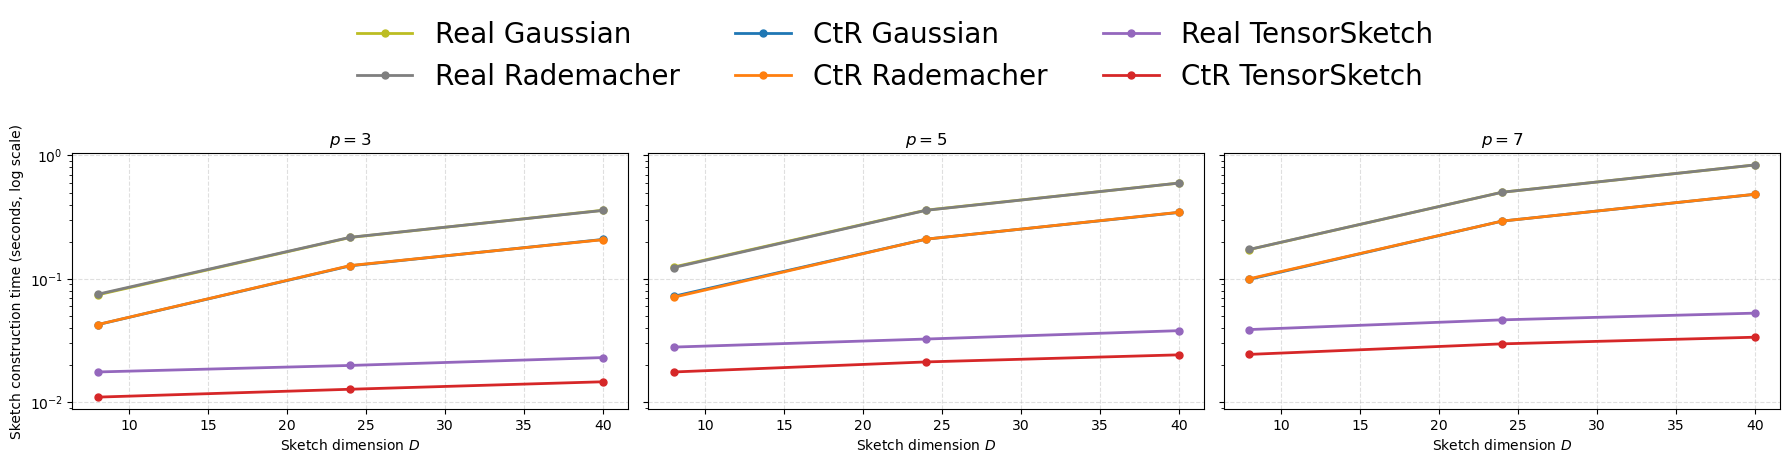

In [7]:
# ============================================================
# Standard library imports
# ============================================================

import random                      # Python random number generator
import math                        # Mathematical functions and constants
import cmath                       # Complex number utilities
import numpy as np                 # Numerical linear algebra
import matplotlib.pyplot as plt    # Plotting library
import time                        # High-resolution timing measurements
import scipy.sparse                # Sparse matrix detection
from sklearn.datasets import fetch_openml  # Dataset loader from OpenML


# ============================================================
# Global configuration
# ============================================================

# Fix random seeds to ensure complete reproducibility
# of all sketch constructions across trials.
random.seed(0)
np.random.seed(0)

# Number of samples used in the experiment
n = 3000

# Degrees of homogeneous polynomial kernel evaluated
p_list = [3, 5, 7]

# Number of independent repetitions per configuration
# Used to compute mean sketch construction time
trials = 50


# ============================================================
# Utility functions
# ============================================================

def l2_normalize(x):
    """
    ℓ2-normalizes a vector.

    Ensures all input vectors lie on the unit sphere.
    This removes scale variation, isolating angular structure.
    """
    nrm = np.linalg.norm(x)
    return x if nrm == 0 else x / nrm


def roots_of_unity():
    """
    Returns a uniformly random 4th root of unity:
        {1, i, -1, -i}

    Used in complex Rademacher projections for CtR sketches.
    """
    return cmath.exp(1j * math.pi / 2 * random.randint(0, 3))


def ctr_stack(Zc):
    """
    Converts complex feature matrix Zc ∈ ℂ^{n×Dc}
    into real-valued representation ∈ ℝ^{n×(2Dc)}
    by concatenating real and imaginary parts.

    Required for compatibility with real-valued pipelines.
    """
    return np.concatenate([Zc.real, Zc.imag], axis=1)


# ============================================================
# Load COD-RNA dataset (OpenML ID: 351)
# ============================================================

print("Downloading cod-rna dataset...")

# Fetch dataset from OpenML repository
dataset = fetch_openml(data_id=351, as_frame=False)

# Convert sparse matrix to dense if necessary
if scipy.sparse.issparse(dataset.data):
    X_raw = dataset.data.toarray()
else:
    X_raw = dataset.data

# Extract feature dimension
d = X_raw.shape[1]
print(f"Detected dimension d={d}")

# ℓ2-normalize first n samples
X = np.array([l2_normalize(X_raw[i])
              for i in range(min(n, len(X_raw)))])

# Update n in case dataset has fewer samples
n = X.shape[0]
print(f"Loaded {n} samples")

# Sketch dimensions tested.
# NOTE: For COD-RNA, d can be large.
# Using D = {d, 3d, 5d} significantly increases computation.
D_vals = [d, 3*d, 5*d]

# Ensure even dimensionality (required for CtR sketches)
D_vals = [D if D % 2 == 0 else D+1 for D in D_vals]


# ============================================================
# Real JL sketches — Unoptimized (loop-based implementation)
# ============================================================

def real_gaussian_features(X, D, p):
    """
    Real Gaussian JL feature map for degree-p polynomial kernel.

    For each of p repetitions:
        - Draw W ~ N(0,1)
        - Compute projections explicitly via nested loops
        - Multiply elementwise across repetitions

    Final normalization: 1/sqrt(D)

    Computational complexity per call:
        O(p * n * D * d)
    """
    n, d = X.shape
    Z = np.ones((n, D))

    for _ in range(p):
        W = np.random.randn(D, d)
        Z *= np.array([[sum(W[j,k]*x[k] for k in range(d))
                        for j in range(D)] for x in X])

    return Z / math.sqrt(D)


def real_rademacher_features(X, D, p):
    """
    Same structure as Gaussian sketch,
    but projection matrix entries are ±1.

    Computational complexity identical to Gaussian case.
    """
    n, d = X.shape
    Z = np.ones((n, D))

    for _ in range(p):
        W = np.random.choice([-1.0,1.0], size=(D,d))
        Z *= np.array([[sum(W[j,k]*x[k] for k in range(d))
                        for j in range(D)] for x in X])

    return Z / math.sqrt(D)


# ============================================================
# Complex-to-Real JL sketches — Unoptimized
# ============================================================

def ctr_gaussian_features(X, D, p):
    """
    CtR Gaussian JL sketch.

    Uses D/2 complex projections and rescales by sqrt(2/D)
    to preserve unbiasedness after conversion to real features.

    Complexity:
        O(p * n * (D/2) * d)
    """
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        W = np.random.randn(Dc,d) + 1j*np.random.randn(Dc,d)
        Zc *= np.array([[sum(W[j,k]*x[k] for k in range(d))
                         for j in range(Dc)] for x in X])

    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


def ctr_rademacher_features(X, D, p):
    """
    Complex Rademacher sketch using roots of unity.
    """
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        W = np.array([[roots_of_unity() for _ in range(d)]
                      for _ in range(Dc)], dtype=complex)

        Zc *= np.array([[sum(W[j,k]*x[k] for k in range(d))
                         for j in range(Dc)] for x in X])

    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


# ============================================================
# TensorSketch implementation
# ============================================================

def countsketch(x, h, s, D):
    """
    Applies CountSketch transform to vector x.

    h : hash indices
    s : random signs or roots of unity
    D : output dimension
    """
    z = [0]*D
    for i in range(len(x)):
        z[h[i]] += s[i]*x[i]
    return z


def real_tensorsketch_features(X, D, p):
    """
    Real TensorSketch via FFT-based convolution.

    Complexity:
        O(p * (nD + D log D))
    """
    n, d = X.shape
    Z_fft = np.ones((n, D), dtype=complex)

    for _ in range(p):
        h = np.random.randint(0,D,size=d)
        s = np.random.choice([-1,1],size=d)

        Z = np.zeros((n,D))
        for i in range(n):
            Z[i] = countsketch(X[i], h, s, D)

        Z_fft *= np.fft.fft(Z, axis=1)

    return np.fft.ifft(Z_fft, axis=1).real / math.sqrt(D)


def ctr_tensorsketch_features(X, D, p):
    """
    CtR TensorSketch variant.
    """
    Dc = D // 2
    n, d = X.shape
    Z_fft = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        h = np.random.randint(0,Dc,size=d)
        s = [roots_of_unity() for _ in range(d)]

        Z = np.zeros((n,Dc), dtype=complex)
        for i in range(n):
            Z[i] = countsketch(X[i], h, s, Dc)

        Z_fft *= np.fft.fft(Z, axis=1)

    Zc = np.fft.ifft(Z_fft, axis=1)
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


# ============================================================
# Timing experiment
# ============================================================

methods = [
    ("Real Gaussian", real_gaussian_features),
    ("Real Rademacher", real_rademacher_features),
    ("CtR Gaussian", ctr_gaussian_features),
    ("CtR Rademacher", ctr_rademacher_features),
    ("Real TensorSketch", real_tensorsketch_features),
    ("CtR TensorSketch", ctr_tensorsketch_features),
]

# Dictionary storing mean construction times
times = {p:{name:[] for name,_ in methods} for p in p_list}

for p in p_list:
    print(f"\n=== Timing p={p} ===")

    for D in D_vals:
        for name, fn in methods:

            tvals = []

            for t in range(trials):

                if t % 10 == 0:
                    print(f"  p={p}, D={D}, method={name}, trial={t}")

                # Measure only feature construction time
                start = time.perf_counter()
                _ = fn(X, D, p)
                tvals.append(time.perf_counter() - start)

            # Store mean runtime across trials
            times[p][name].append(np.mean(tvals))


# ============================================================
# Plot timing results
# ============================================================

COLOR_MAP = {
    "Real Gaussian": "#bcbd22",
    "Real Rademacher": "#7f7f7f",
    "CtR Gaussian": "#1f77b4",
    "CtR Rademacher": "#ff7f0e",
    "Real TensorSketch": "#9467bd",
    "CtR TensorSketch": "#d62728",
}

fig, axes = plt.subplots(1, len(p_list), figsize=(18,4), sharey=True)

for ax, p in zip(axes, p_list):

    for name in times[p]:
        ax.plot(D_vals,
                times[p][name],
                marker="o",
                linewidth=2,
                markersize=5,
                color=COLOR_MAP[name],
                label=name)

    ax.set_title(f"$p={p}$")
    ax.set_xlabel("Sketch dimension $D$")
    ax.set_yscale("log")
    ax.grid(True, linestyle="--", alpha=0.4)

axes[0].set_ylabel("Sketch construction time (seconds, log scale)")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="upper center",
           bbox_to_anchor=(0.5, 1.18),
           ncol=3,
           frameon=False,
           fontsize=20)

plt.tight_layout(rect=[0,0,1,0.88])
plt.savefig("time_codrna_sketches_unoptimized.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

Generating synthetic dataset...
Generated 3000 samples, dimension = 2

=== p = 10 ===
Real Gaussian, p=10, D=100, trial=0
Real Gaussian, p=10, D=100, trial=1
Real Gaussian, p=10, D=100, trial=2
Real Gaussian, p=10, D=100, trial=3
Real Gaussian, p=10, D=100, trial=4
Real Gaussian, p=10, D=100, trial=5
Real Gaussian, p=10, D=100, trial=6
Real Gaussian, p=10, D=100, trial=7
Real Gaussian, p=10, D=100, trial=8
Real Gaussian, p=10, D=100, trial=9
Real Gaussian, p=10, D=100, trial=10
Real Gaussian, p=10, D=100, trial=11
Real Gaussian, p=10, D=100, trial=12
Real Gaussian, p=10, D=100, trial=13
Real Gaussian, p=10, D=100, trial=14
Real Gaussian, p=10, D=100, trial=15
Real Gaussian, p=10, D=100, trial=16
Real Gaussian, p=10, D=100, trial=17
Real Gaussian, p=10, D=100, trial=18
Real Gaussian, p=10, D=100, trial=19
Real Gaussian, p=10, D=300, trial=0
Real Gaussian, p=10, D=300, trial=1
Real Gaussian, p=10, D=300, trial=2
Real Gaussian, p=10, D=300, trial=3
Real Gaussian, p=10, D=300, trial=4
Real

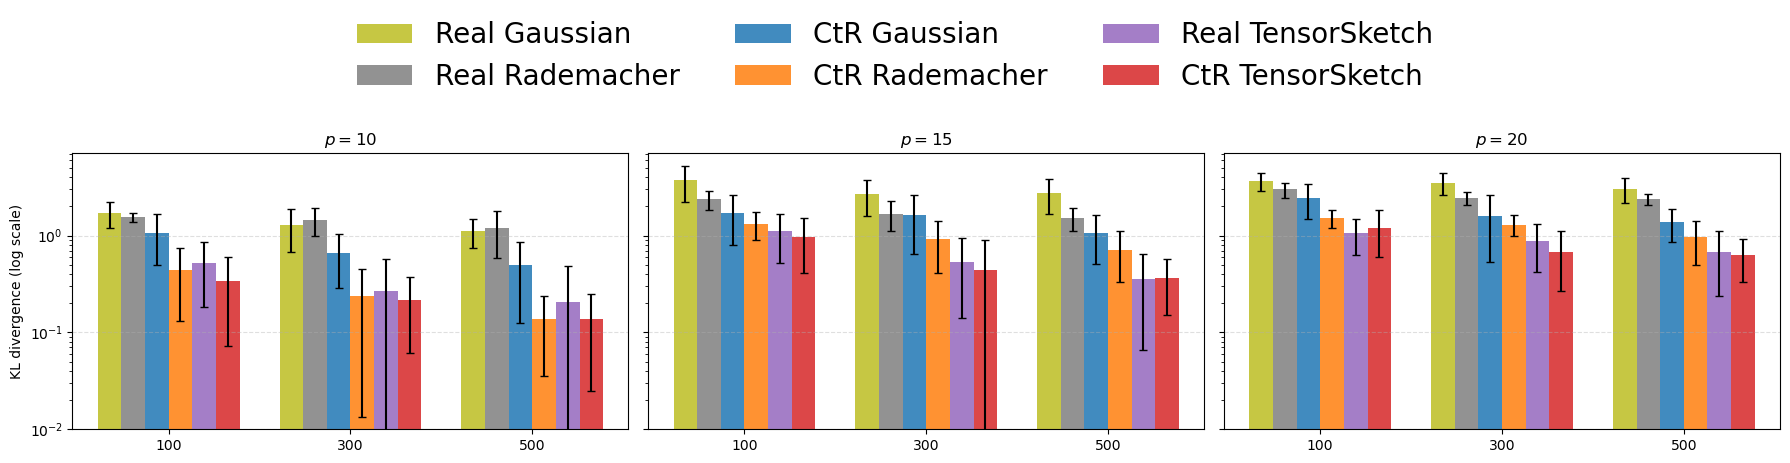

In [13]:
# ============================================================
# Standard library imports
# ============================================================

import random                      # Python random number generator
import math                        # Mathematical functions and constants
import cmath                       # Complex number utilities
import numpy as np                 # Numerical linear algebra
import matplotlib.pyplot as plt    # Plotting utilities


# ============================================================
# Global configuration
# ============================================================

# Fix random seeds to ensure reproducibility across trials.
# This guarantees identical sketch realizations between runs.
random.seed(0)
np.random.seed(0)

# Number of synthetic samples
n = 3000

# Ambient dimension (intentionally small)
# Small d with large p stresses high-degree behavior.
d = 2

# Polynomial degrees evaluated (large degrees relative to d)
p_list = [10, 15, 20]

# Number of independent repetitions per configuration
# Used to compute mean and standard deviation of KL divergence
trials = 20


# ============================================================
# Utility functions
# ============================================================

def l2_normalize(x):
    """
    ℓ2-normalizes a vector.

    Ensures all samples lie on the unit sphere.
    For high-degree polynomial kernels, this prevents
    uncontrolled magnitude explosion.
    """
    norm = np.linalg.norm(x)
    return x if norm == 0 else x / norm


def roots_of_unity():
    """
    Returns a uniformly random 4th root of unity:
        {1, i, -1, -i}

    Used for complex Rademacher projections in CtR sketches.
    """
    return cmath.exp(1j * math.pi / 2 * random.randint(0, 3))


def ctr_stack(Zc):
    """
    Converts complex feature matrix Zc ∈ ℂ^{n×Dc}
    into real-valued representation ∈ ℝ^{n×(2Dc)}
    by concatenating real and imaginary parts.

    This enables reconstruction of real-valued kernels.
    """
    return np.concatenate([Zc.real, Zc.imag], axis=1)


# ============================================================
# Synthetic dataset generation
# ============================================================

print("Generating synthetic dataset...")

# Draw Gaussian samples in ℝ^d
X = np.random.randn(n, d)

# Standardize each coordinate (zero mean, unit variance)
X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-12)

# ℓ2-normalize each sample
# Ensures all vectors lie on unit sphere S^{d-1}
X = np.array([l2_normalize(x) for x in X])

n, d = X.shape
print(f"Generated {n} samples, dimension = {d}")

# Sketch dimensions evaluated.
# Since d is small, D is chosen independently of d.
D_vals = [100, 300, 500]

# Ensure D is even (required for CtR splitting into complex halves)
D_vals = [D if D % 2 == 0 else D+1 for D in D_vals]


# ============================================================
# Exact homogeneous polynomial kernel
# ============================================================

def exact_kernel_matrix(X, p):
    """
    Computes exact degree-p homogeneous polynomial kernel:

        K(x, y) = (xᵀ y)^p

    Returns full n × n Gram matrix.
    """
    return (X @ X.T) ** p


# ============================================================
# KL divergence metric
# ============================================================

def kl_divergence(Kh, K, eps=1e-12):
    """
    Computes KL divergence between normalized Gram matrices.

    Both Gram matrices are interpreted as probability
    distributions after normalization.

    Measures global structural distortion induced by sketching.
    """
    K = np.maximum(K, 0)
    Kh = np.maximum(Kh, 0)

    P = K / (K.sum() + eps)
    Q = Kh / (Kh.sum() + eps)

    return np.sum(P * np.log((P + eps) / (Q + eps)))


# ============================================================
# Real JL sketches — Unoptimized implementation
# ============================================================

def real_gaussian_features(X, D, p):
    """
    Real Gaussian JL feature map for degree-p polynomial kernel.

    For each of p repetitions:
        - Draw Gaussian projection matrix
        - Compute projections explicitly via nested loops
        - Multiply elementwise across repetitions

    Final scaling: 1/sqrt(D)

    Complexity:
        O(p * n * D * d)
    """
    n, d = X.shape
    Z = np.ones((n, D))

    for _ in range(p):
        W = np.random.randn(D, d)
        Z *= np.array([[sum(W[j,k]*x[k] for k in range(d))
                        for j in range(D)] for x in X])

    return Z / math.sqrt(D)


def real_rademacher_features(X, D, p):
    """
    Same structure as Gaussian sketch,
    but projection entries are ±1.
    """
    n, d = X.shape
    Z = np.ones((n, D))

    for _ in range(p):
        W = np.random.choice([-1.0,1.0], size=(D,d))
        Z *= np.array([[sum(W[j,k]*x[k] for k in range(d))
                        for j in range(D)] for x in X])

    return Z / math.sqrt(D)


# ============================================================
# Complex-to-Real JL sketches — Unoptimized
# ============================================================

def ctr_gaussian_features(X, D, p):
    """
    CtR Gaussian JL sketch.

    Uses D/2 complex projections.
    Rescaling by sqrt(2/D) preserves unbiasedness
    after real conversion.
    """
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        W = np.random.randn(Dc,d) + 1j*np.random.randn(Dc,d)
        Zc *= np.array([[sum(W[j,k]*x[k] for k in range(d))
                         for j in range(Dc)] for x in X])

    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


def ctr_rademacher_features(X, D, p):
    """
    CtR Rademacher sketch using random roots of unity.
    """
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        W = np.array([[roots_of_unity() for _ in range(d)]
                      for _ in range(Dc)], dtype=complex)

        Zc *= np.array([[sum(W[j,k]*x[k] for k in range(d))
                         for j in range(Dc)] for x in X])

    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


# ============================================================
# CountSketch primitive
# ============================================================

def countsketch(x, h, s, D):
    """
    Applies CountSketch transform to vector x.
    """
    z = [0]*D
    for i in range(len(x)):
        z[h[i]] += s[i]*x[i]
    return z


# ============================================================
# TensorSketch implementations
# ============================================================

def real_tensorsketch_features(X, D, p):
    """
    Real TensorSketch via FFT-based convolution.

    Complexity:
        O(p * (nD + D log D))
    """
    n, d = X.shape
    Z_fft = np.ones((n, D), dtype=complex)

    for _ in range(p):
        h = np.random.randint(0,D,size=d)
        s = np.random.choice([-1,1],size=d)

        Z = np.zeros((n,D))
        for i in range(n):
            Z[i] = countsketch(X[i], h, s, D)

        Z_fft *= np.fft.fft(Z, axis=1)

    return np.fft.ifft(Z_fft, axis=1).real / math.sqrt(D)


def ctr_tensorsketch_features(X, D, p):
    """
    CtR TensorSketch variant.
    """
    Dc = D // 2
    n, d = X.shape
    Z_fft = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        h = np.random.randint(0,Dc,size=d)
        s = [roots_of_unity() for _ in range(d)]

        Z = np.zeros((n,Dc), dtype=complex)
        for i in range(n):
            Z[i] = countsketch(X[i], h, s, Dc)

        Z_fft *= np.fft.fft(Z, axis=1)

    Zc = np.fft.ifft(Z_fft, axis=1)
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


def kernel_from_features(Z):
    """
    Reconstruct approximate kernel matrix:

        K_hat = Z Zᵀ
    """
    return Z @ Z.T


# ============================================================
# Methods evaluated
# ============================================================

methods = [
    ("Real Gaussian", real_gaussian_features),
    ("Real Rademacher", real_rademacher_features),
    ("CtR Gaussian", ctr_gaussian_features),
    ("CtR Rademacher", ctr_rademacher_features),
    ("Real TensorSketch", real_tensorsketch_features),
    ("CtR TensorSketch", ctr_tensorsketch_features),
]


# ============================================================
# Main experiment loop
# ============================================================

results_mean = {p:{} for p in p_list}
results_std  = {p:{} for p in p_list}

for p in p_list:
    print(f"\n=== p = {p} ===")

    # Compute exact kernel once per degree
    K_true = exact_kernel_matrix(X, p)

    for name, fn in methods:
        means, stds = [], []

        for D in D_vals:
            errs = []

            for t in range(trials):
                print(f"{name}, p={p}, D={D}, trial={t}")

                Z = fn(X, D, p)
                K_hat = kernel_from_features(Z)

                errs.append(kl_divergence(K_hat, K_true))

            means.append(np.mean(errs))
            stds.append(np.std(errs, ddof=1))

        results_mean[p][name] = means
        results_std[p][name]  = stds


# ============================================================
# Plot results
# ============================================================

COLOR_MAP = {
    "Real Gaussian": "#bcbd22",
    "Real Rademacher": "#7f7f7f",
    "CtR Gaussian": "#1f77b4",
    "CtR Rademacher": "#ff7f0e",
    "Real TensorSketch": "#9467bd",
    "CtR TensorSketch": "#d62728",
}

bar_width = 0.13
xpos = np.arange(len(D_vals))

fig, axes = plt.subplots(1, len(p_list), figsize=(18,4), sharey=True)

for ax, p in zip(axes, p_list):
    for i,(name,_) in enumerate(methods):
        ax.bar(xpos+i*bar_width,
               results_mean[p][name],
               bar_width,
               yerr=results_std[p][name],
               capsize=3,
               color=COLOR_MAP[name],
               alpha=0.85,
               label=name)

    ax.set_title(f"$p={p}$")
    ax.set_xticks(xpos + bar_width*(len(methods)-1)/2)
    ax.set_xticklabels(D_vals)
    ax.set_yscale("log")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

axes[0].set_ylabel("KL divergence (log scale)")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="upper center",
           bbox_to_anchor=(0.5,1.18),
           ncol=3,
           frameon=False,
           fontsize=20)

plt.tight_layout(rect=[0,0,1,0.88])
plt.savefig("KL_Divergence_synth_p_CtR.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

Generating synthetic dataset...
Generated 3000 samples, dimension = 2

=== Timing p=10 ===
  p=10, D=100, method=Real Gaussian, trial=0
  p=10, D=100, method=Real Gaussian, trial=5
  p=10, D=100, method=Real Gaussian, trial=10
  p=10, D=100, method=Real Gaussian, trial=15
  p=10, D=100, method=Real Rademacher, trial=0
  p=10, D=100, method=Real Rademacher, trial=5
  p=10, D=100, method=Real Rademacher, trial=10
  p=10, D=100, method=Real Rademacher, trial=15
  p=10, D=100, method=CtR Gaussian, trial=0
  p=10, D=100, method=CtR Gaussian, trial=5
  p=10, D=100, method=CtR Gaussian, trial=10
  p=10, D=100, method=CtR Gaussian, trial=15
  p=10, D=100, method=CtR Rademacher, trial=0
  p=10, D=100, method=CtR Rademacher, trial=5
  p=10, D=100, method=CtR Rademacher, trial=10
  p=10, D=100, method=CtR Rademacher, trial=15
  p=10, D=100, method=Real TensorSketch, trial=0
  p=10, D=100, method=Real TensorSketch, trial=5
  p=10, D=100, method=Real TensorSketch, trial=10
  p=10, D=100, method=Rea

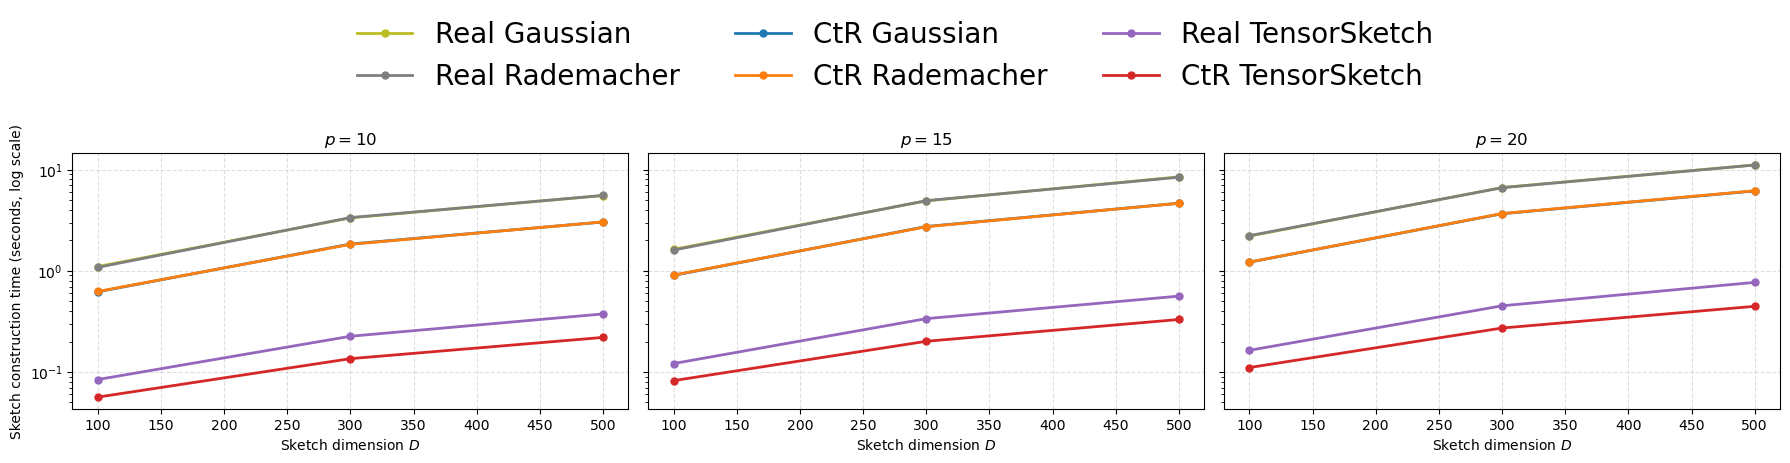

In [14]:
# ============================================================
# Standard library imports
# ============================================================

import random                      # Python random number generator
import math                        # Mathematical constants and functions
import cmath                       # Complex number utilities
import numpy as np                 # Numerical linear algebra library
import matplotlib.pyplot as plt    # Plotting utilities
import time                        # High-resolution timing measurements


# ============================================================
# Global configuration
# ============================================================

# Fix random seeds for full reproducibility.
# Ensures identical sketch realizations across runs.
random.seed(0)
np.random.seed(0)

# Number of synthetic samples
n = 3000

# Ambient dimension (intentionally small)
# Small d combined with large p stresses high-degree behavior.
d = 2

# Polynomial degrees evaluated (high relative to d)
p_list = [10, 15, 20]

# Number of independent repetitions per configuration
# Used to compute mean sketch construction time
trials = 20


# ============================================================
# Utility functions
# ============================================================

def l2_normalize(x):
    """
    ℓ2-normalizes a vector.

    Ensures all samples lie on the unit sphere.
    For high-degree polynomial kernels, this prevents
    uncontrolled magnitude explosion.
    """
    norm = np.linalg.norm(x)
    return x if norm == 0 else x / norm


def roots_of_unity():
    """
    Returns a uniformly random 4th root of unity:
        {1, i, -1, -i}

    Used in complex Rademacher projections for CtR sketches.
    """
    return cmath.exp(1j * math.pi / 2 * random.randint(0, 3))


def ctr_stack(Zc):
    """
    Converts complex feature matrix Zc ∈ ℂ^{n×Dc}
    into real-valued matrix ∈ ℝ^{n×(2Dc)}
    by concatenating real and imaginary parts.

    Required for compatibility with real-valued pipelines.
    """
    return np.concatenate([Zc.real, Zc.imag], axis=1)


# ============================================================
# Synthetic dataset generation
# ============================================================

print("Generating synthetic dataset...")

# Draw Gaussian samples in ℝ^d
X = np.random.randn(n, d)

# Standardize each coordinate to zero mean and unit variance
X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-12)

# ℓ2-normalize each sample
# All vectors lie on the unit sphere S^{d-1}
X = np.array([l2_normalize(x) for x in X])

n, d = X.shape
print(f"Generated {n} samples, dimension = {d}")

# Sketch dimensions evaluated.
# Since d is small, D is chosen independently of d.
D_vals = [100, 300, 500]

# Ensure D is even (required for CtR splitting into complex halves)
D_vals = [D if D % 2 == 0 else D+1 for D in D_vals]


# ============================================================
# Real JL sketches — Unoptimized (explicit loop implementation)
# ============================================================

def real_gaussian_features(X, D, p):
    """
    Real Gaussian JL feature map for degree-p polynomial kernel.

    For each of p repetitions:
        - Draw projection matrix W ~ N(0,1)
        - Compute projections explicitly via nested loops
        - Multiply elementwise across repetitions

    Final scaling: 1/sqrt(D)

    Computational complexity per call:
        O(p * n * D * d)
    """
    n, d = X.shape
    Z = np.ones((n, D))

    for _ in range(p):
        W = np.random.randn(D, d)
        Z *= np.array([[sum(W[j,k]*x[k] for k in range(d))
                        for j in range(D)] for x in X])

    return Z / math.sqrt(D)


def real_rademacher_features(X, D, p):
    """
    Same structure as Gaussian sketch,
    but projection entries are ±1.

    Computational complexity identical to Gaussian case.
    """
    n, d = X.shape
    Z = np.ones((n, D))

    for _ in range(p):
        W = np.random.choice([-1.0,1.0], size=(D,d))
        Z *= np.array([[sum(W[j,k]*x[k] for k in range(d))
                        for j in range(D)] for x in X])

    return Z / math.sqrt(D)


# ============================================================
# Complex-to-Real JL sketches — Unoptimized
# ============================================================

def ctr_gaussian_features(X, D, p):
    """
    CtR Gaussian JL sketch.

    Uses D/2 complex projections.
    Rescaling by sqrt(2/D) preserves unbiasedness
    after real conversion.

    Complexity:
        O(p * n * (D/2) * d)
    """
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        W = np.random.randn(Dc,d) + 1j*np.random.randn(Dc,d)
        Zc *= np.array([[sum(W[j,k]*x[k] for k in range(d))
                         for j in range(Dc)] for x in X])

    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


def ctr_rademacher_features(X, D, p):
    """
    CtR Rademacher sketch using random roots of unity.
    """
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        W = np.array([[roots_of_unity() for _ in range(d)]
                      for _ in range(Dc)], dtype=complex)

        Zc *= np.array([[sum(W[j,k]*x[k] for k in range(d))
                         for j in range(Dc)] for x in X])

    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


# ============================================================
# CountSketch + TensorSketch implementations
# ============================================================

def countsketch(x, h, s, D):
    """
    Applies CountSketch transform to vector x.

    h : hash indices
    s : random signs or roots of unity
    D : output dimension
    """
    z = [0]*D
    for i in range(len(x)):
        z[h[i]] += s[i]*x[i]
    return z


def real_tensorsketch_features(X, D, p):
    """
    Real TensorSketch via FFT-based convolution.

    Complexity:
        O(p * (nD + D log D))
    """
    n, d = X.shape
    Z_fft = np.ones((n, D), dtype=complex)

    for _ in range(p):
        h = np.random.randint(0,D,size=d)
        s = np.random.choice([-1,1],size=d)

        Z = np.zeros((n,D))
        for i in range(n):
            Z[i] = countsketch(X[i], h, s, D)

        Z_fft *= np.fft.fft(Z, axis=1)

    return np.fft.ifft(Z_fft, axis=1).real / math.sqrt(D)


def ctr_tensorsketch_features(X, D, p):
    """
    CtR TensorSketch variant.
    """
    Dc = D // 2
    n, d = X.shape
    Z_fft = np.ones((n, Dc), dtype=complex)

    for _ in range(p):
        h = np.random.randint(0,Dc,size=d)
        s = [roots_of_unity() for _ in range(d)]

        Z = np.zeros((n,Dc), dtype=complex)
        for i in range(n):
            Z[i] = countsketch(X[i], h, s, Dc)

        Z_fft *= np.fft.fft(Z, axis=1)

    Zc = np.fft.ifft(Z_fft, axis=1)
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)


# ============================================================
# Methods evaluated
# ============================================================

methods = [
    ("Real Gaussian", real_gaussian_features),
    ("Real Rademacher", real_rademacher_features),
    ("CtR Gaussian", ctr_gaussian_features),
    ("CtR Rademacher", ctr_rademacher_features),
    ("Real TensorSketch", real_tensorsketch_features),
    ("CtR TensorSketch", ctr_tensorsketch_features),
]


# ============================================================
# Timing experiment — sketch construction only
# ============================================================

# Dictionary storing mean construction times
times = {p: {name: [] for name,_ in methods} for p in p_list}

for p in p_list:
    print(f"\n=== Timing p={p} ===")

    for D in D_vals:
        for name, fn in methods:

            tvals = []

            for t in range(trials):

                if t % 5 == 0:
                    print(f"  p={p}, D={D}, method={name}, trial={t}")

                # Measure only feature construction time
                start = time.perf_counter()
                _ = fn(X, D, p)
                tvals.append(time.perf_counter() - start)

            # Store mean runtime across trials
            times[p][name].append(np.mean(tvals))


# ============================================================
# Plot timing results
# ============================================================

COLOR_MAP = {
    "Real Gaussian": "#bcbd22",
    "Real Rademacher": "#7f7f7f",
    "CtR Gaussian": "#1f77b4",
    "CtR Rademacher": "#ff7f0e",
    "Real TensorSketch": "#9467bd",
    "CtR TensorSketch": "#d62728",
}

fig, axes = plt.subplots(1, len(p_list), figsize=(18,4), sharey=True)

for ax, p in zip(axes, p_list):

    for name in times[p]:
        ax.plot(D_vals,
                times[p][name],
                marker="o",
                linewidth=2,
                markersize=5,
                color=COLOR_MAP[name],
                label=name)

    ax.set_title(f"$p={p}$")
    ax.set_xlabel("Sketch dimension $D$")
    ax.set_yscale("log")
    ax.grid(True, linestyle="--", alpha=0.4)

axes[0].set_ylabel("Sketch construction time (seconds, log scale)")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="upper center",
           bbox_to_anchor=(0.5,1.18),
           ncol=3,
           frameon=False,
           fontsize=20)

plt.tight_layout(rect=[0,0,1,0.88])
plt.savefig("time_synth_p_CtR.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Rebuttal Added

## Classification task

In [22]:
# ============================================================
# Imports for Plotting and Evaluation
# ============================================================
import numpy as np
import time
import matplotlib.pyplot as plt
import math
import cmath
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC, SVC
from sklearn.datasets import make_classification
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

np.random.seed(42)
random.seed(42)

# ============================================================
# 1. Dataset Preparation (Synthetic Classification)
# ============================================================
print("Generating Synthetic Classification Dataset...")
# We use 3000 samples and 20 features. The problem is designed to be 
# non-linear by having informative features but overlapping classes.
X_syn, y_syn = make_classification(
    n_samples=3000, 
    n_features=20, 
    n_informative=10, 
    n_redundant=5, 
    n_classes=2, 
    flip_y=0.05, # Adds 5% noise to make the exact boundary harder
    random_state=42
)


# Standardize and L2 Normalize to ensure kernel stability
scaler_initial = StandardScaler()
X_syn = scaler_initial.fit_transform(X_syn)
X_syn = normalize(X_syn, norm='l2')

# Train/Test Split (70/30)
Xtr, Xte, ytr, yte = train_test_split(X_syn, y_syn, test_size=0.3, stratify=y_syn, random_state=42)

print(f"Train shape: {Xtr.shape}, Test shape: {Xte.shape}")

# ============================================================
# 2. Sketching Functions
# ============================================================
def roots_of_unity(): return cmath.exp(1j * math.pi / 2 * random.randint(0, 3))
def ctr_stack(Zc): return np.concatenate([Zc.real, Zc.imag], axis=1)

def countsketch(x, h, s, D):
    z = [0]*D
    for i in range(len(x)): z[h[i]] += s[i]*x[i]
    return z

def real_tensorsketch_features(X, D, p):
    n, d = X.shape
    Z_fft = np.ones((n, D), dtype=complex)
    for _ in range(p):
        h = np.random.randint(0,D,size=d)
        s = np.random.choice([-1,1],size=d)
        Z = np.zeros((n,D))
        for i in range(n): Z[i] = countsketch(X[i], h, s, D)
        Z_fft *= np.fft.fft(Z, axis=1)
    return np.fft.ifft(Z_fft, axis=1).real / math.sqrt(D)

def ctr_tensorsketch_features(X, D, p):
    Dc = D // 2
    n, d = X.shape
    Z_fft = np.ones((n, Dc), dtype=complex)
    for _ in range(p):
        h = np.random.randint(0,Dc,size=d)
        s = [roots_of_unity() for _ in range(d)]
        Z = np.zeros((n,Dc), dtype=complex)
        for i in range(n): Z[i] = countsketch(X[i], h, s, Dc)
        Z_fft *= np.fft.fft(Z, axis=1)
    Zc = np.fft.ifft(Z_fft, axis=1)
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)

def ctr_gaussian_features(X, D, p):
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)
    for _ in range(p):
        W = np.random.randn(Dc,d) + 1j*np.random.randn(Dc,d)
        Zc *= np.array([[sum(W[j,k]*x[k] for k in range(d)) for j in range(Dc)] for x in X])
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)

def ctr_rademacher_features(X, D, p):
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)
    for _ in range(p):
        W = np.array([[roots_of_unity() for _ in range(d)] for _ in range(Dc)], dtype=complex)
        Zc *= np.array([[sum(W[j,k]*x[k] for k in range(d)) for j in range(Dc)] for x in X])
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)

# --- Naive Exact Kernel Computation ---
def naive_poly_kernel(X1, X2, p):
    """Computes exact polynomial kernel naively using explicit loops."""
    n1, d = X1.shape
    n2 = X2.shape[0]
    K = np.zeros((n1, n2))
    for i in range(n1):
        for j in range(n2):
            K[i, j] = sum(X1[i, k] * X2[j, k] for k in range(d)) ** p
    return K

# ============================================================
# 3. Experiment Loop
# ============================================================
methods = {
    "TensorSketch (Real)": real_tensorsketch_features,
    "TensorSketch (CtR)": ctr_tensorsketch_features,
    "JL (CtR Rademacher)": ctr_rademacher_features,
    "JL (CtR Gaussian)": ctr_gaussian_features,
}

p = 15     # Polynomial degree
D = 64    # Sketch dimension
results = {}

print(f"\nRunning Time vs Accuracy Benchmark (p={p}, D={D})...")

# --- Exact Polynomial Kernel Baseline ---
print(f"{'Exact Poly Kernel':20s} | Computing (Naively, this will take time)...")
t0_exact = time.perf_counter()
Ktr = naive_poly_kernel(Xtr, Xtr, p)
Kte = naive_poly_kernel(Xte, Xtr, p)
kernel_time = time.perf_counter() - t0_exact

svc = SVC(kernel='precomputed')
t1_exact = time.perf_counter()
svc.fit(Ktr, ytr)
exact_train_time = time.perf_counter() - t1_exact

exact_total_time = kernel_time + exact_train_time
exact_acc = accuracy_score(yte, svc.predict(Kte))

results["Exact Poly Kernel"] = {"Accuracy": exact_acc, "Time": exact_total_time}
print(f"{'Exact Poly Kernel':20s} | Accuracy: {exact_acc:.4f} | Time: {exact_total_time:.4f}s")

# --- Sketching Methods ---
for name, func in methods.items():
    t0 = time.perf_counter()
    Ztr = func(Xtr, D, p)
    Zte = func(Xte, D, p)
    sketch_time = time.perf_counter() - t0
    
    # Scale Features for SVM stability
    scaler = StandardScaler()
    Ztr_scaled = scaler.fit_transform(Ztr)
    Zte_scaled = scaler.transform(Zte)
    
    # Linear Classifier
    clf = LinearSVC(C=0.1, dual=False, max_iter=3000)
    t1 = time.perf_counter()
    clf.fit(Ztr_scaled, ytr)
    train_time = time.perf_counter() - t1
    
    total_time = sketch_time + train_time
    acc = accuracy_score(yte, clf.predict(Zte_scaled))
    
    results[name] = {"Accuracy": acc, "Time": total_time}
    print(f"{name:20s} | Accuracy: {acc:.4f} | Time: {total_time:.4f}s")

Generating Synthetic Classification Dataset...
Train shape: (2100, 20), Test shape: (900, 20)

Running Time vs Accuracy Benchmark (p=15, D=64)...
Exact Poly Kernel    | Computing (Naively, this will take time)...
Exact Poly Kernel    | Accuracy: 0.8756 | Time: 16.0724s
TensorSketch (Real)  | Accuracy: 0.4911 | Time: 0.2390s
TensorSketch (CtR)   | Accuracy: 0.5289 | Time: 0.1479s
JL (CtR Rademacher)  | Accuracy: 0.5011 | Time: 3.8279s
JL (CtR Gaussian)    | Accuracy: 0.4978 | Time: 3.7708s


In [25]:
# ============================================================
# Imports for Plotting and Evaluation
# ============================================================
import numpy as np
import time
import matplotlib.pyplot as plt
import math
import cmath
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC, SVC
from sklearn.datasets import make_classification
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

np.random.seed(42)
random.seed(42)

# ============================================================
# 1. Dataset Preparation (Synthetic Classification)
# ============================================================
print("Generating Synthetic Classification Dataset...")
# We use 3000 samples and 20 features. The problem is designed to be 
# non-linear by having informative features but overlapping classes.
X_syn, y_syn = make_classification(
    n_samples=3000, 
    n_features=10, 
    n_informative=5, 
    n_redundant=5, 
    n_classes=2, 
    flip_y=0.05, # Adds 5% noise to make the exact boundary harder
    random_state=42
)


# Standardize and L2 Normalize to ensure kernel stability
scaler_initial = StandardScaler()
X_syn = scaler_initial.fit_transform(X_syn)
X_syn = normalize(X_syn, norm='l2')

# Train/Test Split (70/30)
Xtr, Xte, ytr, yte = train_test_split(X_syn, y_syn, test_size=0.3, stratify=y_syn, random_state=42)

print(f"Train shape: {Xtr.shape}, Test shape: {Xte.shape}")

# ============================================================
# 2. Sketching Functions
# ============================================================
def roots_of_unity(): return cmath.exp(1j * math.pi / 2 * random.randint(0, 3))
def ctr_stack(Zc): return np.concatenate([Zc.real, Zc.imag], axis=1)

def countsketch(x, h, s, D):
    z = [0]*D
    for i in range(len(x)): z[h[i]] += s[i]*x[i]
    return z

def real_tensorsketch_features(X, D, p):
    n, d = X.shape
    Z_fft = np.ones((n, D), dtype=complex)
    for _ in range(p):
        h = np.random.randint(0,D,size=d)
        s = np.random.choice([-1,1],size=d)
        Z = np.zeros((n,D))
        for i in range(n): Z[i] = countsketch(X[i], h, s, D)
        Z_fft *= np.fft.fft(Z, axis=1)
    return np.fft.ifft(Z_fft, axis=1).real / math.sqrt(D)

def ctr_tensorsketch_features(X, D, p):
    Dc = D // 2
    n, d = X.shape
    Z_fft = np.ones((n, Dc), dtype=complex)
    for _ in range(p):
        h = np.random.randint(0,Dc,size=d)
        s = [roots_of_unity() for _ in range(d)]
        Z = np.zeros((n,Dc), dtype=complex)
        for i in range(n): Z[i] = countsketch(X[i], h, s, Dc)
        Z_fft *= np.fft.fft(Z, axis=1)
    Zc = np.fft.ifft(Z_fft, axis=1)
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)

def ctr_gaussian_features(X, D, p):
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)
    for _ in range(p):
        W = np.random.randn(Dc,d) + 1j*np.random.randn(Dc,d)
        Zc *= np.array([[sum(W[j,k]*x[k] for k in range(d)) for j in range(Dc)] for x in X])
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)

def ctr_rademacher_features(X, D, p):
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)
    for _ in range(p):
        W = np.array([[roots_of_unity() for _ in range(d)] for _ in range(Dc)], dtype=complex)
        Zc *= np.array([[sum(W[j,k]*x[k] for k in range(d)) for j in range(Dc)] for x in X])
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)

# --- Naive Exact Kernel Computation ---
def naive_poly_kernel(X1, X2, p):
    """Computes exact polynomial kernel naively using explicit loops."""
    n1, d = X1.shape
    n2 = X2.shape[0]
    K = np.zeros((n1, n2))
    for i in range(n1):
        for j in range(n2):
            K[i, j] = sum(X1[i, k] * X2[j, k] for k in range(d)) ** p
    return K

# ============================================================
# 3. Experiment Loop
# ============================================================
methods = {
    "TensorSketch (Real)": real_tensorsketch_features,
    "TensorSketch (CtR)": ctr_tensorsketch_features,
    "JL (CtR Rademacher)": ctr_rademacher_features,
    "JL (CtR Gaussian)": ctr_gaussian_features,
}

p = 25     # Polynomial degree
D = 64    # Sketch dimension
results = {}

print(f"\nRunning Time vs Accuracy Benchmark (p={p}, D={D})...")

# --- Exact Polynomial Kernel Baseline ---
print(f"{'Exact Poly Kernel':20s} | Computing (Naively, this will take time)...")
t0_exact = time.perf_counter()
Ktr = naive_poly_kernel(Xtr, Xtr, p)
Kte = naive_poly_kernel(Xte, Xtr, p)
kernel_time = time.perf_counter() - t0_exact

svc = SVC(kernel='precomputed')
t1_exact = time.perf_counter()
svc.fit(Ktr, ytr)
exact_train_time = time.perf_counter() - t1_exact

exact_total_time = kernel_time + exact_train_time
exact_acc = accuracy_score(yte, svc.predict(Kte))

results["Exact Poly Kernel"] = {"Accuracy": exact_acc, "Time": exact_total_time}
print(f"{'Exact Poly Kernel':20s} | Accuracy: {exact_acc:.4f} | Time: {exact_total_time:.4f}s")

# --- Sketching Methods ---
for name, func in methods.items():
    t0 = time.perf_counter()
    Ztr = func(Xtr, D, p)
    Zte = func(Xte, D, p)
    sketch_time = time.perf_counter() - t0
    
    # Scale Features for SVM stability
    scaler = StandardScaler()
    Ztr_scaled = scaler.fit_transform(Ztr)
    Zte_scaled = scaler.transform(Zte)
    
    # Linear Classifier
    clf = LinearSVC(C=0.1, dual=False, max_iter=3000)
    t1 = time.perf_counter()
    clf.fit(Ztr_scaled, ytr)
    train_time = time.perf_counter() - t1
    
    total_time = sketch_time + train_time
    acc = accuracy_score(yte, clf.predict(Zte_scaled))
    
    results[name] = {"Accuracy": acc, "Time": total_time}
    print(f"{name:20s} | Accuracy: {acc:.4f} | Time: {total_time:.4f}s")

Generating Synthetic Classification Dataset...
Train shape: (2100, 10), Test shape: (900, 10)

Running Time vs Accuracy Benchmark (p=25, D=64)...
Exact Poly Kernel    | Computing (Naively, this will take time)...
Exact Poly Kernel    | Accuracy: 0.8567 | Time: 8.5344s
TensorSketch (Real)  | Accuracy: 0.4978 | Time: 0.2763s
TensorSketch (CtR)   | Accuracy: 0.5044 | Time: 0.1733s
JL (CtR Rademacher)  | Accuracy: 0.4567 | Time: 3.3204s
JL (CtR Gaussian)    | Accuracy: 0.4889 | Time: 3.2954s


## KL divergence numerical table generation

In [4]:
# ============================================================
# Standard library imports
# ============================================================
import random                  # Python RNG
import math                    # Basic mathematical functions
import cmath                   # Complex number support
import numpy as np             # Numerical linear algebra
import pandas as pd            # Tabular data formatting

# ============================================================
# Global configuration
# ============================================================
# Fix random seeds for reproducibility of all experiments.
random.seed(0)
np.random.seed(0)

# Dataset parameters
n = 1000   # Number of samples
d = 10     # Ambient dimension (Increased to stress cross-term variance)

# Degrees of polynomial kernel to evaluate
p_list = [15, 20, 25, 30]

# Number of independent trials per configuration
trials = 20

# ============================================================
# Utility functions
# ============================================================
def l2_normalize(x):
    """ℓ2-normalizes a vector."""
    norm = np.linalg.norm(x)
    return x if norm == 0 else x / norm

def roots_of_unity():
    """Returns a random 4th root of unity: {1, i, -1, -i}"""
    return cmath.exp(1j * math.pi / 2 * random.randint(0, 3))

def ctr_stack(Zc):
    """Converts complex feature matrix into real-valued representation"""
    return np.concatenate([Zc.real, Zc.imag], axis=1)

# ============================================================
# Synthetic Dataset Generation (VITAL FIX)
# ============================================================
print(f"Generating positive orthant synthetic dataset (n={n}, d={d})...")

# Draw samples from a strictly positive uniform distribution.
# WHY: This ensures inner products are positive, preventing the high-degree 
# odd polynomials from generating negative values. This prevents np.maximum() 
# from clipping the outputs to 0, which previously masked the massive 
# noise/variance of classical Real TensorSketch.
X = np.random.uniform(0.1, 1.0, size=(n, d))

# ℓ2-normalize each sample to lie on the unit sphere
X = np.array([l2_normalize(x) for x in X])

print(f"Dataset ready. Shape: {X.shape}")

# Embedding dimensions tested 
D_vals = [64]
# Ensure D is even (required for CtR which splits into complex halves)
D_vals = [D if D % 2 == 0 else D+1 for D in D_vals]

# ============================================================
# Exact Polynomial Kernel & KL Divergence Metric
# ============================================================
def exact_kernel_matrix(X, p):
    return (X @ X.T) ** p

def kl_divergence(Kh, K, eps=1e-12):
    """Computes KL divergence between normalized Gram matrices."""
    K = np.maximum(K, 0)
    Kh = np.maximum(Kh, 0)
    P = K / (K.sum() + eps)
    Q = Kh / (Kh.sum() + eps)
    return np.sum(P * np.log((P + eps) / (Q + eps)))

# ============================================================
# Sketches
# ============================================================
def real_gaussian_features(X, D, p):
    n, d = X.shape
    Z = np.ones((n, D))
    for _ in range(p):
        W = np.random.randn(D, d)
        Z *= np.array([[sum(W[j, k] * x[k] for k in range(d)) for j in range(D)] for x in X])
    return Z / math.sqrt(D)

def real_rademacher_features(X, D, p):
    n, d = X.shape
    Z = np.ones((n, D))
    for _ in range(p):
        W = np.random.choice([-1.0, 1.0], size=(D, d))
        Z *= np.array([[sum(W[j, k] * x[k] for k in range(d)) for j in range(D)] for x in X])
    return Z / math.sqrt(D)

def ctr_gaussian_features(X, D, p):
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)
    for _ in range(p):
        W = np.random.randn(Dc, d) + 1j*np.random.randn(Dc, d)
        Zc *= np.array([[sum(W[j, k] * x[k] for k in range(d)) for j in range(Dc)] for x in X])
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)

def ctr_rademacher_features(X, D, p):
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)
    for _ in range(p):
        W = np.array([[roots_of_unity() for _ in range(d)] for _ in range(Dc)], dtype=complex)
        Zc *= np.array([[sum(W[j, k] * x[k] for k in range(d)) for j in range(Dc)] for x in X])
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)

def countsketch(x, h, s, D):
    z = [0] * D
    for i in range(len(x)):
        z[h[i]] += s[i] * x[i]
    return z

def real_tensorsketch_features(X, D, p):
    n, d = X.shape
    Z_fft = np.ones((n, D), dtype=complex)
    for _ in range(p):
        h = np.random.randint(0, D, size=d)
        s = np.random.choice([-1, 1], size=d)
        Z = np.zeros((n, D))
        for i in range(n):
            Z[i] = countsketch(X[i], h, s, D)
        Z_fft *= np.fft.fft(Z, axis=1)
    return np.fft.ifft(Z_fft, axis=1).real / math.sqrt(D)

def ctr_tensorsketch_features(X, D, p):
    Dc = D // 2
    n, d = X.shape
    Z_fft = np.ones((n, Dc), dtype=complex)
    for _ in range(p):
        h = np.random.randint(0, Dc, size=d)
        s = [roots_of_unity() for _ in range(d)]
        Z = np.zeros((n, Dc), dtype=complex)
        for i in range(n):
            Z[i] = countsketch(X[i], h, s, Dc)
        Z_fft *= np.fft.fft(Z, axis=1)
    Zc = np.fft.ifft(Z_fft, axis=1)
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)

def kernel_from_features(Z):
    return Z @ Z.T

methods = [
    ("Real Gaussian", real_gaussian_features),
    ("Real Rademacher", real_rademacher_features),
    ("CtR Gaussian", ctr_gaussian_features),
    ("CtR Rademacher", ctr_rademacher_features),
    ("Real TensorSketch", real_tensorsketch_features),
    ("CtR TensorSketch", ctr_tensorsketch_features),
]

# ============================================================
# Main experiment loop
# ============================================================
results_data = []

for p in p_list:
    print(f"\n=== Computing Exact Kernel for p = {p} ===")
    K_true = exact_kernel_matrix(X, p)

    for D in D_vals:
        print(f"  Running Sketch Dimension D = {D}...")
        trial_errors = {name: [] for name, _ in methods}

        for t in range(trials):
            for name, fn in methods:
                Z = fn(X, D, p)
                K_hat = kernel_from_features(Z)
                err = kl_divergence(K_hat, K_true)
                trial_errors[name].append(err)

        # Identify the most stable method among the TensorSketch variants
        ts_variances = {
            "Real TensorSketch": np.var(trial_errors["Real TensorSketch"], ddof=1),
            "CtR TensorSketch": np.var(trial_errors["CtR TensorSketch"], ddof=1)
        }
        best_ts_method = min(ts_variances, key=ts_variances.get)

        for name in trial_errors:
            # Highlight the better TensorSketch method
            display_name = f"⭐ {name}" if name == best_ts_method else name
            
            results_data.append({
                "Degree (p)": p,
                "Dimension (D)": D,
                "Method": display_name,
                "Mean KL Div": np.mean(trial_errors[name]),
                "Variance": np.var(trial_errors[name], ddof=1)
            })

# ============================================================
# Generate Numeric Rebuttal Output
# ============================================================
df = pd.DataFrame(results_data)

# Sort logically to group by degree, then dimension
df['Raw_Method'] = df['Method'].str.replace("⭐ ", "")
df['Raw_Method'] = pd.Categorical(df['Raw_Method'], categories=[m[0] for m in methods], ordered=True)
df = df.sort_values(by=["Degree (p)", "Dimension (D)", "Raw_Method"]).drop(columns=['Raw_Method'])

pd.set_option('display.float_format', '{:.6e}'.format)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

print("\n" + "="*95)
print("KL DIVERGENCE SUMMARY (POSITIVE ORTHANT SYNTHETIC DATASET: n=1000, d=10)")
print("⭐ = Lowest Variance between Real TensorSketch and CtR TensorSketch")
print("Note: Log-scale plots visually compress variance differences. This table reveals the mathematical gap.")
print("="*95)

pivot_df = df.set_index(["Degree (p)", "Dimension (D)", "Method"])
print(pivot_df)
print("="*95)

Generating positive orthant synthetic dataset (n=1000, d=10)...
Dataset ready. Shape: (1000, 10)

=== Computing Exact Kernel for p = 15 ===
  Running Sketch Dimension D = 64...

=== Computing Exact Kernel for p = 20 ===
  Running Sketch Dimension D = 64...

=== Computing Exact Kernel for p = 25 ===
  Running Sketch Dimension D = 64...

=== Computing Exact Kernel for p = 30 ===
  Running Sketch Dimension D = 64...

KL DIVERGENCE SUMMARY (POSITIVE ORTHANT SYNTHETIC DATASET: n=1000, d=10)
⭐ = Lowest Variance between Real TensorSketch and CtR TensorSketch
Note: Log-scale plots visually compress variance differences. This table reveals the mathematical gap.
                                              Mean KL Div     Variance
Degree (p) Dimension (D) Method                                       
15         64            Real Gaussian       7.327412e+00 2.633916e-01
                         Real Rademacher     7.114840e+00 3.839411e-01
                         CtR Gaussian        4.926219e+

## Frobenius norm relative error

In [4]:
# ============================================================
# Standard library imports
# ============================================================
import random                  # Python RNG
import math                    # Basic mathematical functions
import cmath                   # Complex number support
import numpy as np             # Numerical linear algebra
import pandas as pd            # Tabular data formatting
import urllib.request          # Dataset download from URL
from sklearn.preprocessing import StandardScaler  # Feature standardization

# ============================================================
# Global configuration
# ============================================================
# Fix random seeds for reproducibility of all experiments.
# random.seed(0)
# np.random.seed(0)

# Dataset parameters
n = 1000   # Number of samples to use from the dataset

# Degrees of polynomial kernel to evaluate
p_list = [15, 20, 25, 30]

# Number of independent trials per configuration
trials = 20

# ============================================================
# Utility functions
# ============================================================
def l2_normalize(x):
    """ℓ2-normalizes a vector."""
    norm = np.linalg.norm(x)
    return x if norm == 0 else x / norm

def roots_of_unity():
    """Returns a random 4th root of unity: {1, i, -1, -i}"""
    return cmath.exp(1j * math.pi / 2 * random.randint(0, 3))

def ctr_stack(Zc):
    """Converts complex feature matrix into real-valued representation"""
    return np.concatenate([Zc.real, Zc.imag], axis=1)

# ============================================================
# Load MAGIC Dataset
# ============================================================
print(f"Downloading and reading MAGIC dataset (using first n={n} samples)...")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data"
lines = urllib.request.urlopen(url).read().decode().strip().split("\n")

X_list = []
# Extract first n samples and first 10 real-valued features
for line in lines[:n]:
    feats = list(map(float, line.split(",")[:10]))
    X_list.append(feats)

X_raw = np.array(X_list, dtype=float)
d = X_raw.shape[1]

# Standardize features (zero mean, unit variance)
X = StandardScaler().fit_transform(X_raw)

# ℓ2-normalize each sample to lie on the unit sphere
X = np.array([l2_normalize(x) for x in X])

print(f"Dataset ready. Shape: {X.shape}, detected dimension d={d}")

# Embedding dimensions tested 
D_vals = [128]
# Ensure D is even (required for CtR which splits into complex halves)
D_vals = [D if D % 2 == 0 else D+1 for D in D_vals]

# ============================================================
# Exact Polynomial Kernel & Frobenius Error Metric
# ============================================================
def exact_kernel_matrix(X, p):
    return (X @ X.T) ** p

def frobenius_relative_error(K_hat, K, eps=1e-12):
    """Computes Frobenius normalized relative error between Gram matrices."""
    norm_K = np.linalg.norm(K, 'fro')
    return np.linalg.norm(K - K_hat, 'fro') / (norm_K + eps)

# ============================================================
# Sketches
# ============================================================
def real_gaussian_features(X, D, p):
    n, d = X.shape
    Z = np.ones((n, D))
    for _ in range(p):
        W = np.random.randn(D, d)
        Z *= np.array([[sum(W[j, k] * x[k] for k in range(d)) for j in range(D)] for x in X])
    return Z / math.sqrt(D)

def real_rademacher_features(X, D, p):
    n, d = X.shape
    Z = np.ones((n, D))
    for _ in range(p):
        W = np.random.choice([-1.0, 1.0], size=(D, d))
        Z *= np.array([[sum(W[j, k] * x[k] for k in range(d)) for j in range(D)] for x in X])
    return Z / math.sqrt(D)

def ctr_gaussian_features(X, D, p):
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)
    for _ in range(p):
        W = np.random.randn(Dc, d) + 1j*np.random.randn(Dc, d)
        Zc *= np.array([[sum(W[j, k] * x[k] for k in range(d)) for j in range(Dc)] for x in X])
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)

def ctr_rademacher_features(X, D, p):
    Dc = D // 2
    n, d = X.shape
    Zc = np.ones((n, Dc), dtype=complex)
    for _ in range(p):
        W = np.array([[roots_of_unity() for _ in range(d)] for _ in range(Dc)], dtype=complex)
        Zc *= np.array([[sum(W[j, k] * x[k] for k in range(d)) for j in range(Dc)] for x in X])
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)

def countsketch(x, h, s, D):
    z = [0] * D
    for i in range(len(x)):
        z[h[i]] += s[i] * x[i]
    return z

def real_tensorsketch_features(X, D, p):
    n, d = X.shape
    Z_fft = np.ones((n, D), dtype=complex)
    for _ in range(p):
        h = np.random.randint(0, D, size=d)
        s = np.random.choice([-1, 1], size=d)
        Z = np.zeros((n, D))
        for i in range(n):
            Z[i] = countsketch(X[i], h, s, D)
        Z_fft *= np.fft.fft(Z, axis=1)
    return np.fft.ifft(Z_fft, axis=1).real / math.sqrt(D)

def ctr_tensorsketch_features(X, D, p):
    Dc = D // 2
    n, d = X.shape
    Z_fft = np.ones((n, Dc), dtype=complex)
    for _ in range(p):
        h = np.random.randint(0, Dc, size=d)
        s = [roots_of_unity() for _ in range(d)]
        Z = np.zeros((n, Dc), dtype=complex)
        for i in range(n):
            Z[i] = countsketch(X[i], h, s, Dc)
        Z_fft *= np.fft.fft(Z, axis=1)
    Zc = np.fft.ifft(Z_fft, axis=1)
    Zc *= math.sqrt(2.0 / D)
    return ctr_stack(Zc)

def kernel_from_features(Z):
    return Z @ Z.T

methods = [
    ("Real Gaussian", real_gaussian_features),
    ("Real Rademacher", real_rademacher_features),
    ("CtR Gaussian", ctr_gaussian_features),
    ("CtR Rademacher", ctr_rademacher_features),
    ("Real TensorSketch", real_tensorsketch_features),
    ("CtR TensorSketch", ctr_tensorsketch_features),
]

# ============================================================
# Main experiment loop
# ============================================================
results_data = []

for p in p_list:
    print(f"\n=== Computing Exact Kernel for p = {p} ===")
    K_true = exact_kernel_matrix(X, p)

    for D in D_vals:
        print(f"  Running Sketch Dimension D = {D}...")
        trial_errors = {name: [] for name, _ in methods}

        for t in range(trials):
            for name, fn in methods:
                Z = fn(X, D, p)
                K_hat = kernel_from_features(Z)
                err = frobenius_relative_error(K_hat, K_true)
                trial_errors[name].append(err)

        # Identify the most stable method among the TensorSketch variants
        ts_variances = {
            "Real TensorSketch": np.var(trial_errors["Real TensorSketch"], ddof=1),
            "CtR TensorSketch": np.var(trial_errors["CtR TensorSketch"], ddof=1)
        }
        best_ts_method = min(ts_variances, key=ts_variances.get)

        for name in trial_errors:
            # Highlight the better TensorSketch method
            display_name = f"⭐ {name}" if name == best_ts_method else name
            
            results_data.append({
                "Degree (p)": p,
                "Dimension (D)": D,
                "Method": display_name,
                "Mean Frob. Error": np.mean(trial_errors[name]),
                "Variance": np.var(trial_errors[name], ddof=1)
            })

# ============================================================
# Generate Numeric Rebuttal Output
# ============================================================
df = pd.DataFrame(results_data)

# Sort logically to group by degree, then dimension
df['Raw_Method'] = df['Method'].str.replace("⭐ ", "")
df['Raw_Method'] = pd.Categorical(df['Raw_Method'], categories=[m[0] for m in methods], ordered=True)
df = df.sort_values(by=["Degree (p)", "Dimension (D)", "Raw_Method"]).drop(columns=['Raw_Method'])

pd.set_option('display.float_format', '{:.6e}'.format)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

print("\n" + "="*95)
print(f"FROBENIUS NORMALIZED RELATIVE ERROR SUMMARY (MAGIC DATASET: n={n}, d={d})")
print("⭐ = Lowest Variance between Real TensorSketch and CtR TensorSketch")
print("Note: Log-scale plots visually compress variance differences. This table reveals the mathematical gap.")
print("="*95)

pivot_df = df.set_index(["Degree (p)", "Dimension (D)", "Method"])
print(pivot_df)
print("="*95)

Dataset ready. Shape: (1000, 10), detected dimension d=10

=== Computing Exact Kernel for p = 15 ===
  Running Sketch Dimension D = 128...

=== Computing Exact Kernel for p = 20 ===
  Running Sketch Dimension D = 128...

=== Computing Exact Kernel for p = 25 ===
  Running Sketch Dimension D = 128...

=== Computing Exact Kernel for p = 30 ===
  Running Sketch Dimension D = 128...

FROBENIUS NORMALIZED RELATIVE ERROR SUMMARY (MAGIC DATASET: n=1000, d=10)
⭐ = Lowest Variance between Real TensorSketch and CtR TensorSketch
Note: Log-scale plots visually compress variance differences. This table reveals the mathematical gap.
                                              Mean Frob. Error     Variance
Degree (p) Dimension (D) Method                                            
15         128           Real Gaussian            7.862085e+00 1.393523e+02
                         Real Rademacher          4.532394e+00 1.057016e+01
                         CtR Gaussian             3.044604e+05 5.3053